# Training Classification Models

This file is responsible for training the network traffic classification models to be used for performing the attacks.
Make sure to add the dataset files in the `dataset` folder.

## Parameters

In [ ]:
from utils.parameters import *

# Load datasets

In [ ]:
from utils.helpers.load_datasets import load_all_datasets

datasets = load_all_datasets(copies=n_copies, random_state=random_state)

# Creating the neural networks

In [ ]:
from utils.helpers.load_networks import load_networks, network_types

for dataset_name, dataset in datasets.items():
    load_networks(
        dataset=dataset,
        dataset_name=dataset_name,
        batch_size=batch_size,
        n_hidden_layers=n_hidden_layers,
        n_neurons=n_neurons,
        dropout_prob_fnn=dropout_prob_fnn,
        dropout_prob_snn=dropout_prob_snn,
        learning_rate_fnn=learning_rate_fnn,
        learning_rate_snn=learning_rate_snn,
        random_state=random_state
    )

# Training the neural networks

In [ ]:
for dataset_name, dataset in datasets.items():
    print(f"Training models for dataset: {dataset_name}")
    if dataset["fnn_trainer"].epoch < training_epochs:
        dataset["fnn_trainer"].train_network(epochs=training_epochs - dataset["fnn_trainer"].epoch)
    if dataset["snn_trainer"].epoch < training_epochs:
        dataset["snn_trainer"].train_network(epochs=training_epochs - dataset["snn_trainer"].epoch)

Training models for dataset: ton_iot
Training models for dataset: bot_iot
Training models for dataset: ctu_13
Training models for dataset: nsl_kdd
Training models for dataset: ton_iot_copy_1
Training models for dataset: bot_iot_copy_1
Training models for dataset: ctu_13_copy_1
Training models for dataset: nsl_kdd_copy_1
Training models for dataset: ton_iot_copy_2
Training models for dataset: bot_iot_copy_2
Training models for dataset: ctu_13_copy_2
Training models for dataset: nsl_kdd_copy_2
Training models for dataset: ton_iot_copy_3
Training models for dataset: bot_iot_copy_3
Training models for dataset: ctu_13_copy_3
Training models for dataset: nsl_kdd_copy_3
Training models for dataset: ton_iot_copy_4
Training models for dataset: bot_iot_copy_4
Training models for dataset: ctu_13_copy_4
Training models for dataset: nsl_kdd_copy_4
Training models for dataset: ton_iot_copy_5
Training models for dataset: bot_iot_copy_5
Training models for dataset: ctu_13_copy_5
Training models for da

## Calculate metrics

In [ ]:
import pandas as pd
import json

metrics = {}

for dataset_name, dataset in datasets.items():
    base_dataset_name = dataset_name.split('_copy_')[0]
    
    if base_dataset_name not in metrics:
        metrics[base_dataset_name] = {}
        for network in network_types:
            metrics[base_dataset_name][network] = []
    
    for network in network_types:
        print(f"Evaluating {network.upper()} for dataset: {dataset_name}")
        
        network_report = dataset[f"{network}_trainer"].get_classification_report(dataset["dataPreparer"], output_dict=True)
        metrics[base_dataset_name][network].append(network_report)
    
with open(classification_results_filename, "w") as f:
    json.dump(metrics, f, indent=4)
    
for dataset_name, reports in metrics.items():
    for network in network_types:
        df = pd.DataFrame([metric['weighted avg'] for metric in reports[network]])
        df = df.agg(['mean', 'std'])
        reports[f"avg_{network}"] = df
        
        print(f"Dataset: {dataset_name}")
        print(f"{network.upper()} Metrics:")
        print(df)
        print("\n" + "="*50 + "\n")

Evaluating FNN for dataset: ton_iot
Evaluating SNN for dataset: ton_iot
Evaluating FNN for dataset: bot_iot
Evaluating SNN for dataset: bot_iot
Evaluating FNN for dataset: ctu_13
Evaluating SNN for dataset: ctu_13
Evaluating FNN for dataset: nsl_kdd
Evaluating SNN for dataset: nsl_kdd
Evaluating FNN for dataset: ton_iot_copy_1
Evaluating SNN for dataset: ton_iot_copy_1
Evaluating FNN for dataset: bot_iot_copy_1
Evaluating SNN for dataset: bot_iot_copy_1
Evaluating FNN for dataset: ctu_13_copy_1
Evaluating SNN for dataset: ctu_13_copy_1
Evaluating FNN for dataset: nsl_kdd_copy_1
Evaluating SNN for dataset: nsl_kdd_copy_1
Evaluating FNN for dataset: ton_iot_copy_2
Evaluating SNN for dataset: ton_iot_copy_2
Evaluating FNN for dataset: bot_iot_copy_2
Evaluating SNN for dataset: bot_iot_copy_2
Evaluating FNN for dataset: ctu_13_copy_2
Evaluating SNN for dataset: ctu_13_copy_2
Evaluating FNN for dataset: nsl_kdd_copy_2
Evaluating SNN for dataset: nsl_kdd_copy_2
Evaluating FNN for dataset: to

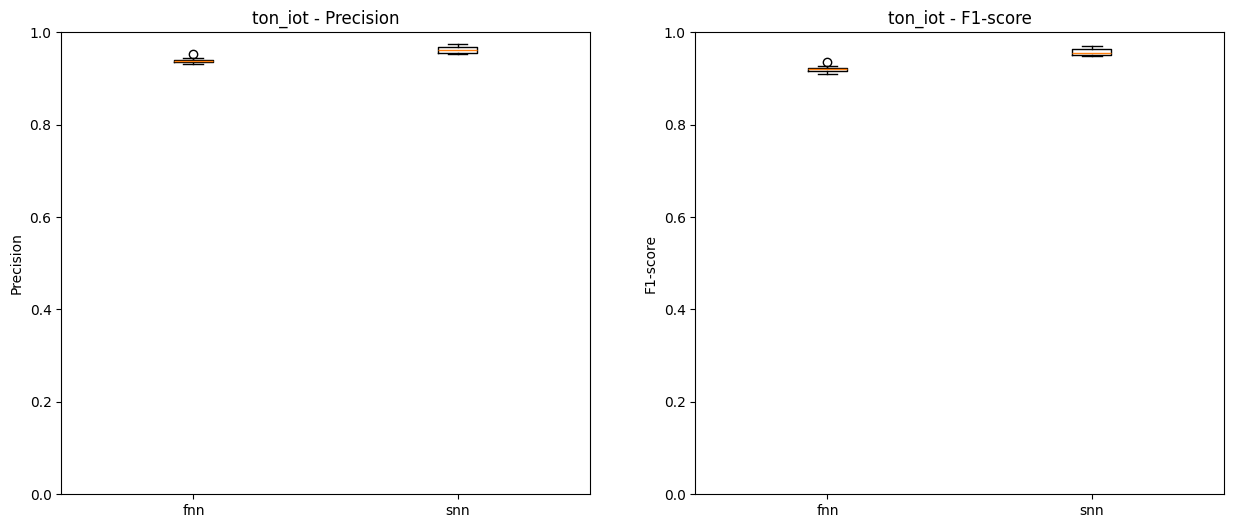

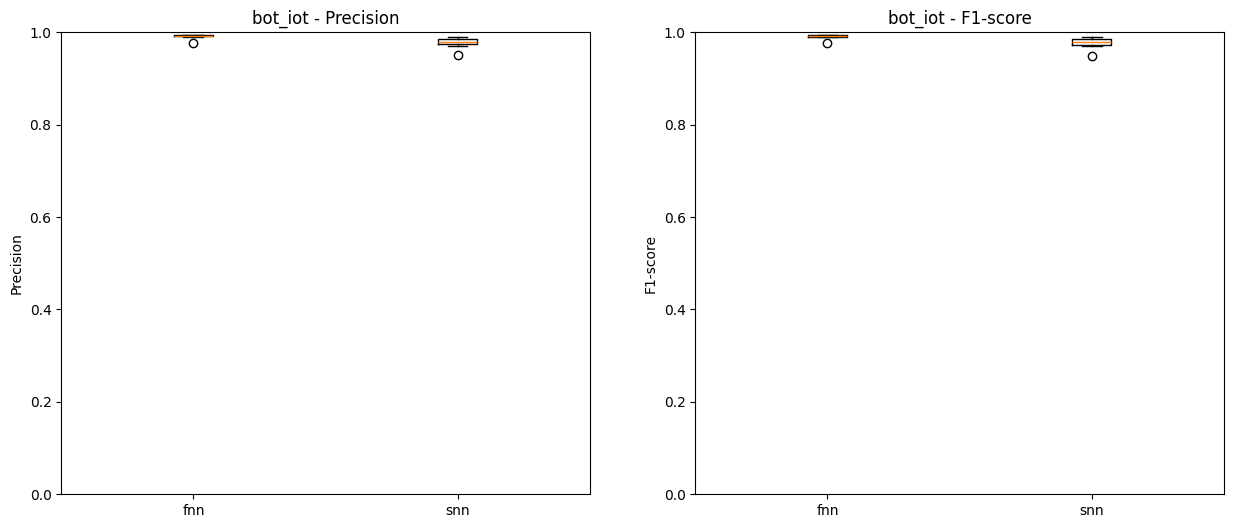

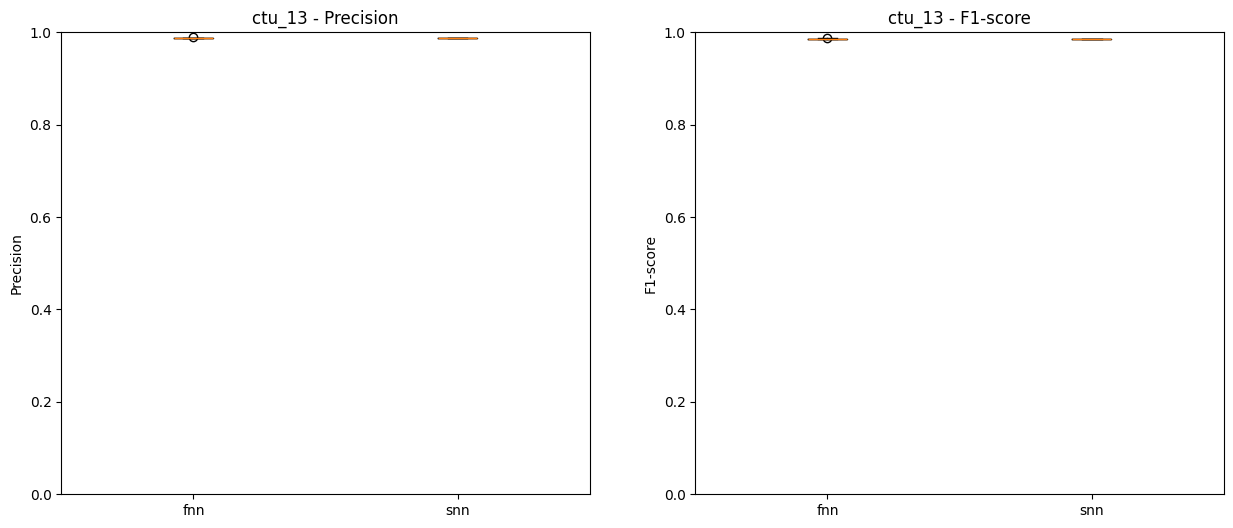

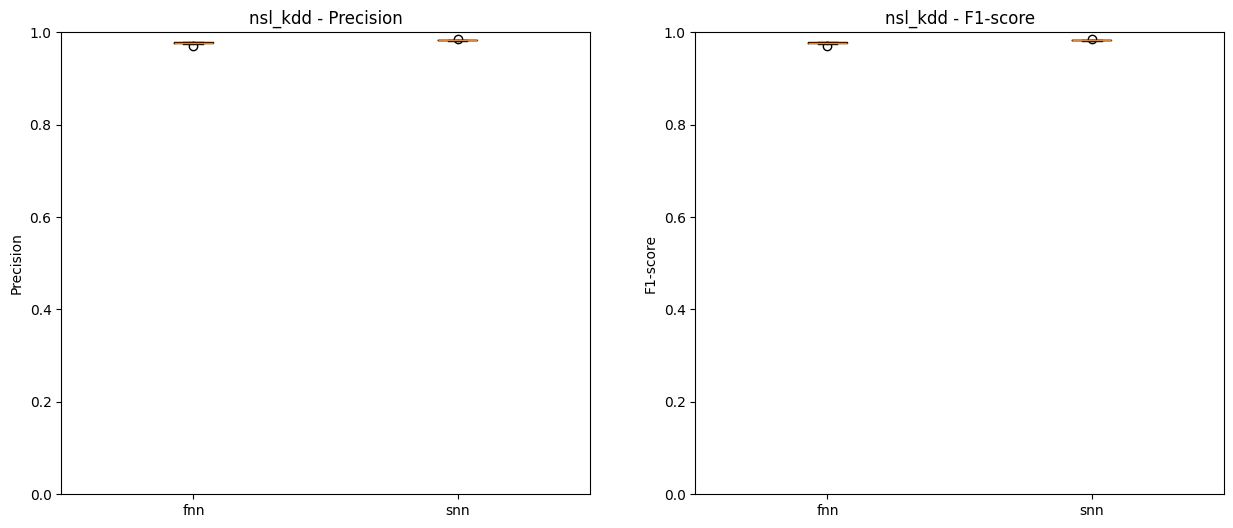

In [ ]:
import matplotlib.pyplot as plt

metrics_to_plot = ['precision', 'f1-score']

# Plot precision and f1-score, showing mean and std
for dataset_name, reports in metrics.items():    
    # Create a figure for each dataset
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(15, 6))
    
    for metric, ax in zip(metrics_to_plot, axes):
        data = {}
        
        for network in network_types:
            data[network] = [report['weighted avg'][metric] for report in reports[network]]
            
        # Create boxplot
        ax.boxplot(data.values(), tick_labels=data.keys())
        ax.set_title(f"{dataset_name} - {metric.capitalize()}")
        ax.set_ylabel(metric.capitalize())
        ax.set_ylim(0, 1)
        

## Plotting the confusion matrix

ton_iot:
Evaluating FNN for dataset: ton_iot


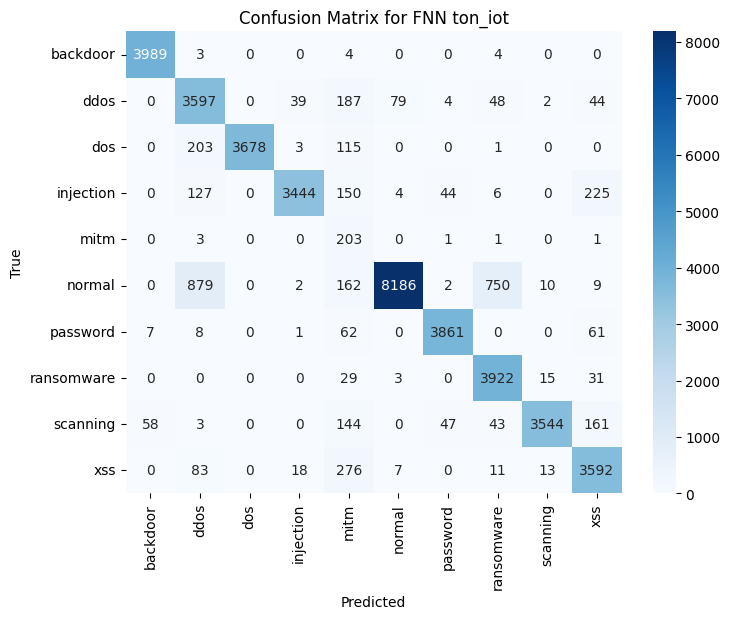

              precision    recall  f1-score   support

    backdoor       0.98      1.00      0.99      4000
        ddos       0.73      0.90      0.81      4000
         dos       1.00      0.92      0.96      4000
   injection       0.98      0.86      0.92      4000
        mitm       0.15      0.97      0.26       209
      normal       0.99      0.82      0.90     10000
    password       0.98      0.97      0.97      4000
  ransomware       0.82      0.98      0.89      4000
    scanning       0.99      0.89      0.93      4000
         xss       0.87      0.90      0.88      4000

    accuracy                           0.90     42209
   macro avg       0.85      0.92      0.85     42209
weighted avg       0.93      0.90      0.91     42209



Evaluating SNN for dataset: ton_iot


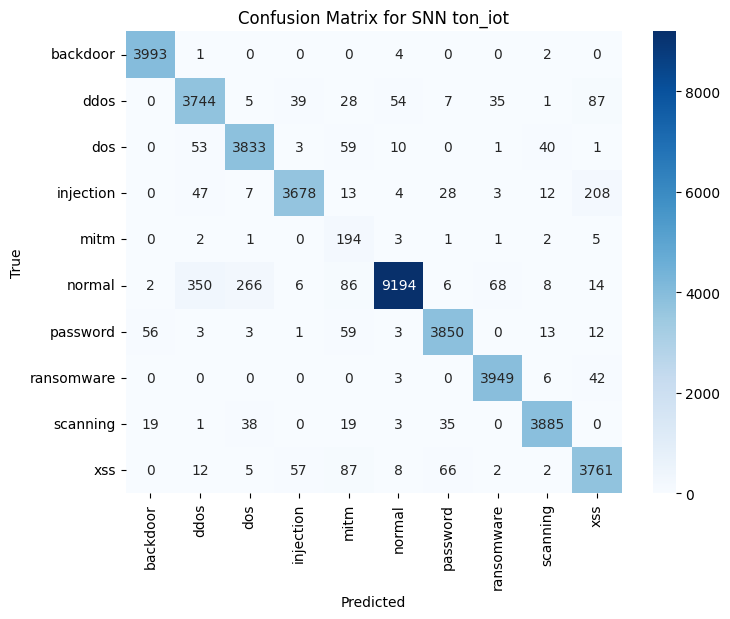

              precision    recall  f1-score   support

    backdoor       0.98      1.00      0.99      4000
        ddos       0.89      0.94      0.91      4000
         dos       0.92      0.96      0.94      4000
   injection       0.97      0.92      0.95      4000
        mitm       0.36      0.93      0.51       209
      normal       0.99      0.92      0.95     10000
    password       0.96      0.96      0.96      4000
  ransomware       0.97      0.99      0.98      4000
    scanning       0.98      0.97      0.97      4000
         xss       0.91      0.94      0.93      4000

    accuracy                           0.95     42209
   macro avg       0.89      0.95      0.91     42209
weighted avg       0.96      0.95      0.95     42209



bot_iot:
Evaluating FNN for dataset: bot_iot


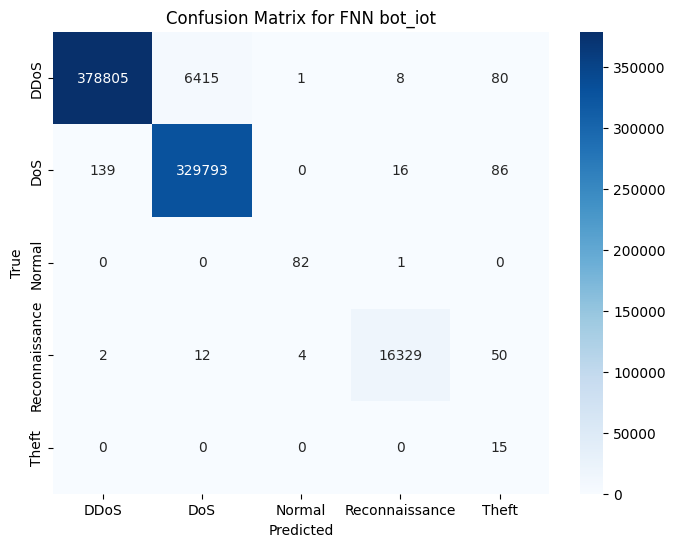

                precision    recall  f1-score   support

          DDoS       1.00      0.98      0.99    385309
           DoS       0.98      1.00      0.99    330034
        Normal       0.94      0.99      0.96        83
Reconnaissance       1.00      1.00      1.00     16397
         Theft       0.06      1.00      0.12        15

      accuracy                           0.99    731838
     macro avg       0.80      0.99      0.81    731838
  weighted avg       0.99      0.99      0.99    731838



Evaluating SNN for dataset: bot_iot


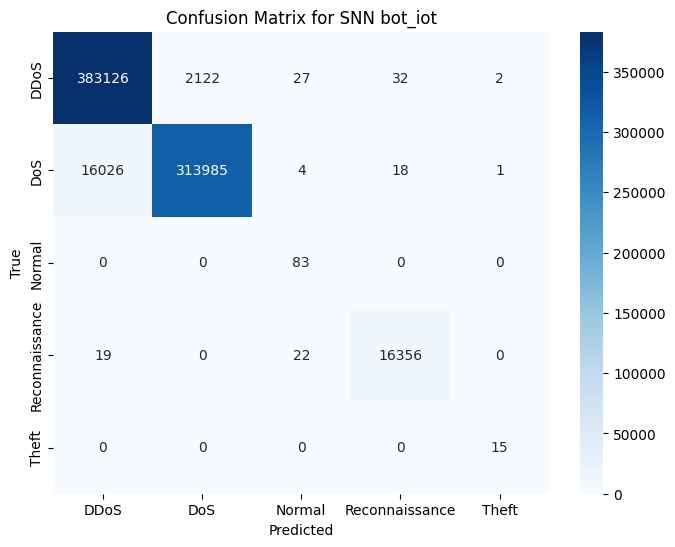

                precision    recall  f1-score   support

          DDoS       0.96      0.99      0.98    385309
           DoS       0.99      0.95      0.97    330034
        Normal       0.61      1.00      0.76        83
Reconnaissance       1.00      1.00      1.00     16397
         Theft       0.83      1.00      0.91        15

      accuracy                           0.98    731838
     macro avg       0.88      0.99      0.92    731838
  weighted avg       0.98      0.98      0.97    731838



ctu_13:
Evaluating FNN for dataset: ctu_13


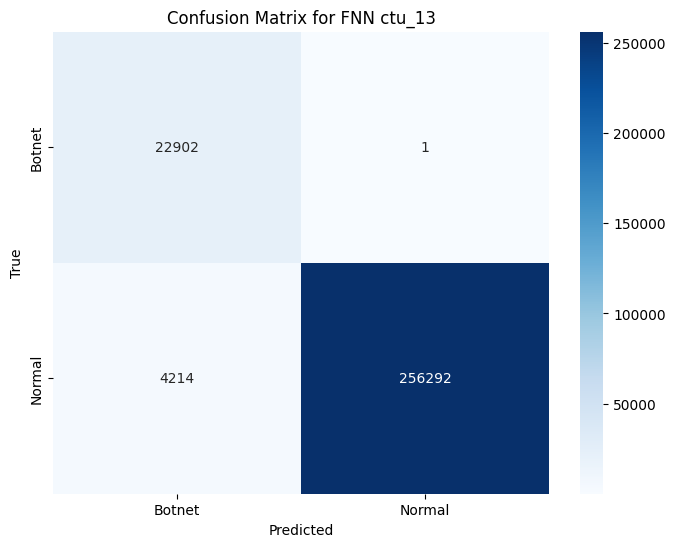

              precision    recall  f1-score   support

      Botnet       0.84      1.00      0.92     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.99    283409
   macro avg       0.92      0.99      0.95    283409
weighted avg       0.99      0.99      0.99    283409



Evaluating SNN for dataset: ctu_13


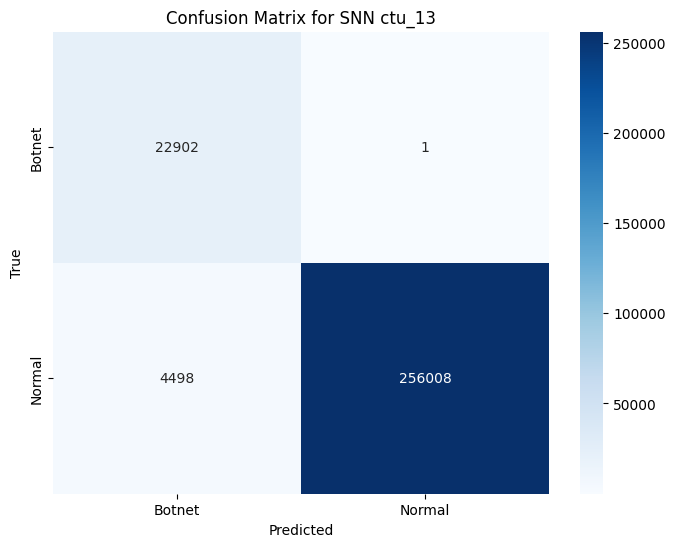

              precision    recall  f1-score   support

      Botnet       0.84      1.00      0.91     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.98    283409
   macro avg       0.92      0.99      0.95    283409
weighted avg       0.99      0.98      0.98    283409



nsl_kdd:
Evaluating FNN for dataset: nsl_kdd


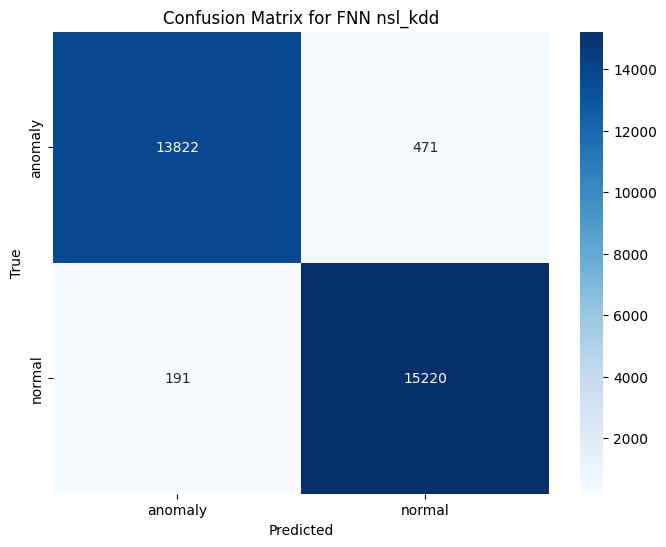

              precision    recall  f1-score   support

     anomaly       0.99      0.97      0.98     14293
      normal       0.97      0.99      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704



Evaluating SNN for dataset: nsl_kdd


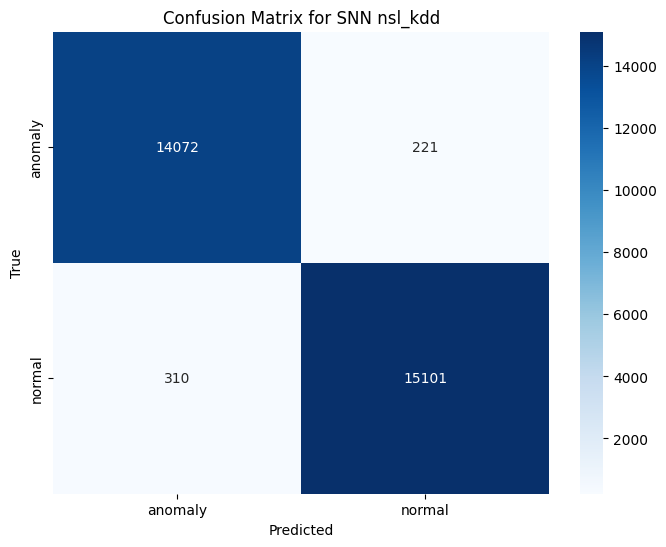

              precision    recall  f1-score   support

     anomaly       0.98      0.98      0.98     14293
      normal       0.99      0.98      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704



ton_iot_copy_1:
Evaluating FNN for dataset: ton_iot_copy_1


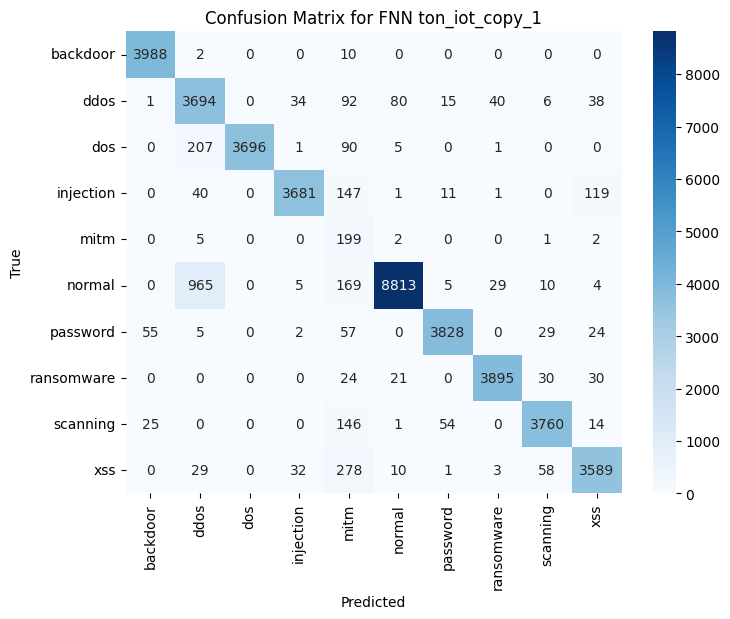

              precision    recall  f1-score   support

    backdoor       0.98      1.00      0.99      4000
        ddos       0.75      0.92      0.83      4000
         dos       1.00      0.92      0.96      4000
   injection       0.98      0.92      0.95      4000
        mitm       0.16      0.95      0.28       209
      normal       0.99      0.88      0.93     10000
    password       0.98      0.96      0.97      4000
  ransomware       0.98      0.97      0.98      4000
    scanning       0.97      0.94      0.95      4000
         xss       0.94      0.90      0.92      4000

    accuracy                           0.93     42209
   macro avg       0.87      0.94      0.88     42209
weighted avg       0.95      0.93      0.94     42209



Evaluating SNN for dataset: ton_iot_copy_1


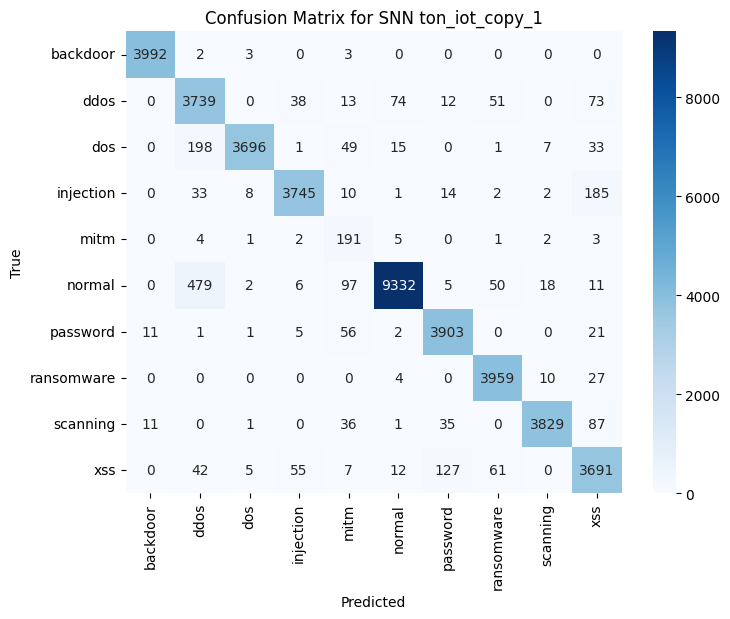

              precision    recall  f1-score   support

    backdoor       0.99      1.00      1.00      4000
        ddos       0.83      0.93      0.88      4000
         dos       0.99      0.92      0.96      4000
   injection       0.97      0.94      0.95      4000
        mitm       0.41      0.91      0.57       209
      normal       0.99      0.93      0.96     10000
    password       0.95      0.98      0.96      4000
  ransomware       0.96      0.99      0.97      4000
    scanning       0.99      0.96      0.97      4000
         xss       0.89      0.92      0.91      4000

    accuracy                           0.95     42209
   macro avg       0.90      0.95      0.91     42209
weighted avg       0.96      0.95      0.95     42209



bot_iot_copy_1:
Evaluating FNN for dataset: bot_iot_copy_1


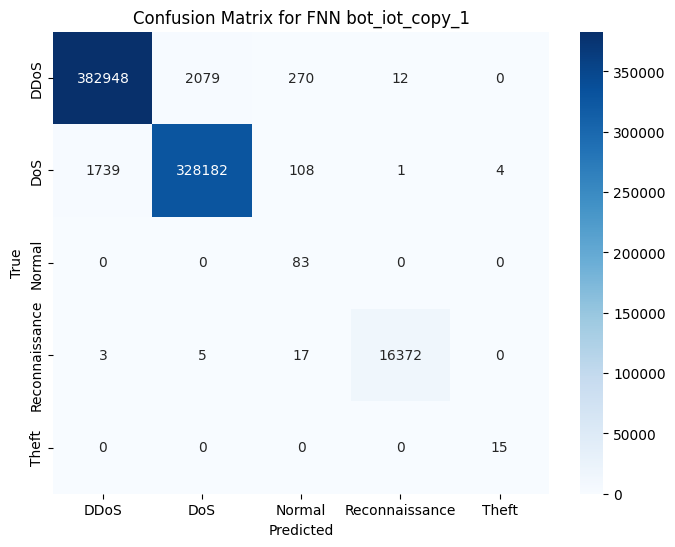

                precision    recall  f1-score   support

          DDoS       1.00      0.99      0.99    385309
           DoS       0.99      0.99      0.99    330034
        Normal       0.17      1.00      0.30        83
Reconnaissance       1.00      1.00      1.00     16397
         Theft       0.79      1.00      0.88        15

      accuracy                           0.99    731838
     macro avg       0.79      1.00      0.83    731838
  weighted avg       0.99      0.99      0.99    731838



Evaluating SNN for dataset: bot_iot_copy_1


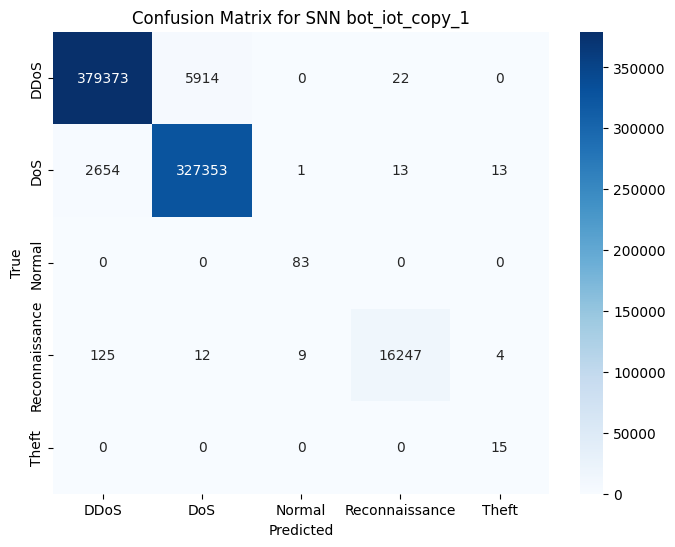

                precision    recall  f1-score   support

          DDoS       0.99      0.98      0.99    385309
           DoS       0.98      0.99      0.99    330034
        Normal       0.89      1.00      0.94        83
Reconnaissance       1.00      0.99      0.99     16397
         Theft       0.47      1.00      0.64        15

      accuracy                           0.99    731838
     macro avg       0.87      0.99      0.91    731838
  weighted avg       0.99      0.99      0.99    731838



ctu_13_copy_1:
Evaluating FNN for dataset: ctu_13_copy_1


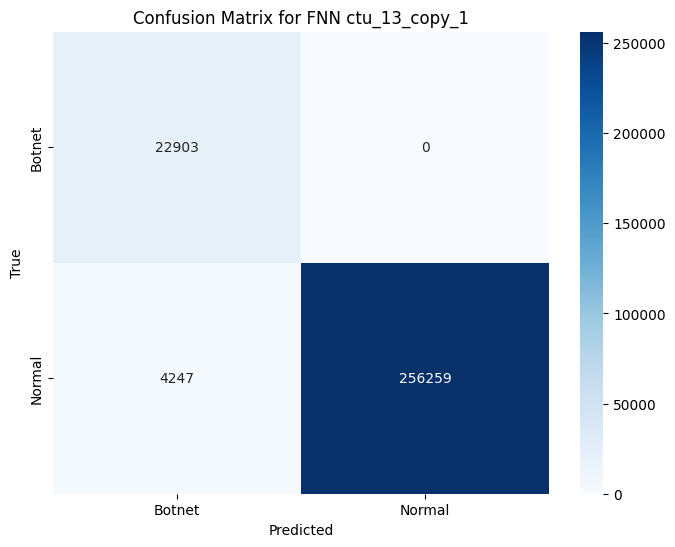

              precision    recall  f1-score   support

      Botnet       0.84      1.00      0.92     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.99    283409
   macro avg       0.92      0.99      0.95    283409
weighted avg       0.99      0.99      0.99    283409



Evaluating SNN for dataset: ctu_13_copy_1


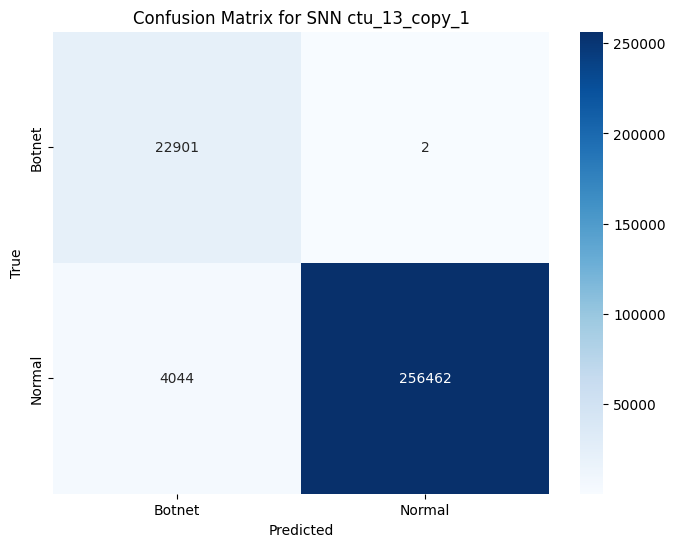

              precision    recall  f1-score   support

      Botnet       0.85      1.00      0.92     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.99    283409
   macro avg       0.92      0.99      0.96    283409
weighted avg       0.99      0.99      0.99    283409



nsl_kdd_copy_1:
Evaluating FNN for dataset: nsl_kdd_copy_1


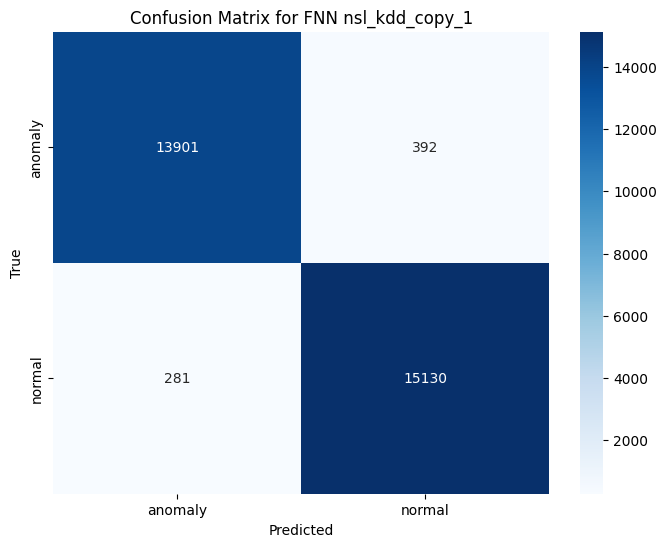

              precision    recall  f1-score   support

     anomaly       0.98      0.97      0.98     14293
      normal       0.97      0.98      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704



Evaluating SNN for dataset: nsl_kdd_copy_1


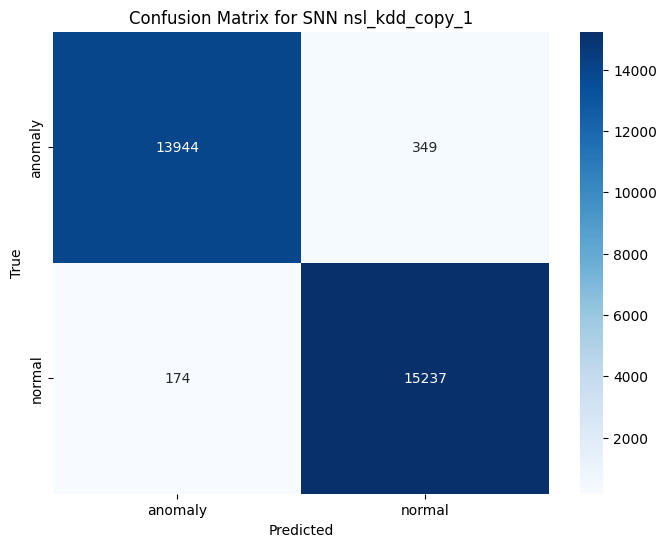

              precision    recall  f1-score   support

     anomaly       0.99      0.98      0.98     14293
      normal       0.98      0.99      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704



ton_iot_copy_2:
Evaluating FNN for dataset: ton_iot_copy_2


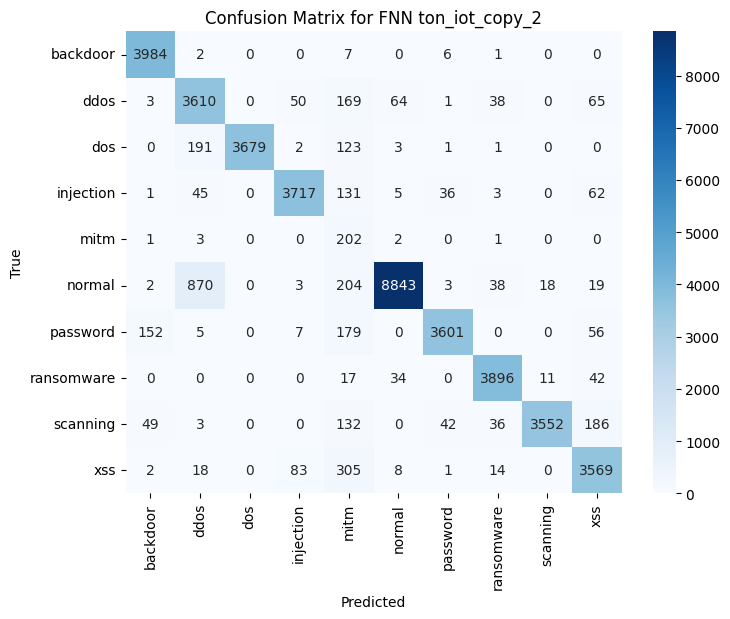

              precision    recall  f1-score   support

    backdoor       0.95      1.00      0.97      4000
        ddos       0.76      0.90      0.83      4000
         dos       1.00      0.92      0.96      4000
   injection       0.96      0.93      0.95      4000
        mitm       0.14      0.97      0.24       209
      normal       0.99      0.88      0.93     10000
    password       0.98      0.90      0.94      4000
  ransomware       0.97      0.97      0.97      4000
    scanning       0.99      0.89      0.94      4000
         xss       0.89      0.89      0.89      4000

    accuracy                           0.92     42209
   macro avg       0.86      0.93      0.86     42209
weighted avg       0.95      0.92      0.93     42209



Evaluating SNN for dataset: ton_iot_copy_2


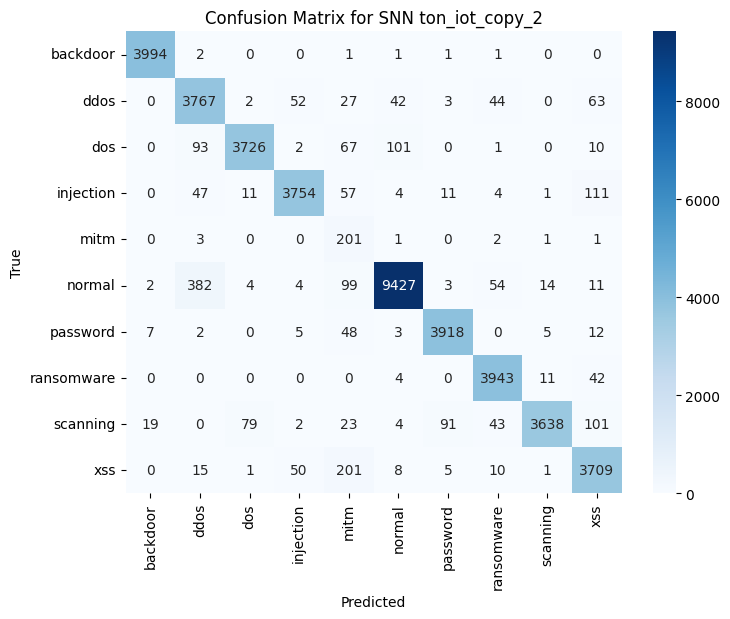

              precision    recall  f1-score   support

    backdoor       0.99      1.00      1.00      4000
        ddos       0.87      0.94      0.91      4000
         dos       0.97      0.93      0.95      4000
   injection       0.97      0.94      0.95      4000
        mitm       0.28      0.96      0.43       209
      normal       0.98      0.94      0.96     10000
    password       0.97      0.98      0.98      4000
  ransomware       0.96      0.99      0.97      4000
    scanning       0.99      0.91      0.95      4000
         xss       0.91      0.93      0.92      4000

    accuracy                           0.95     42209
   macro avg       0.89      0.95      0.90     42209
weighted avg       0.96      0.95      0.95     42209



bot_iot_copy_2:
Evaluating FNN for dataset: bot_iot_copy_2


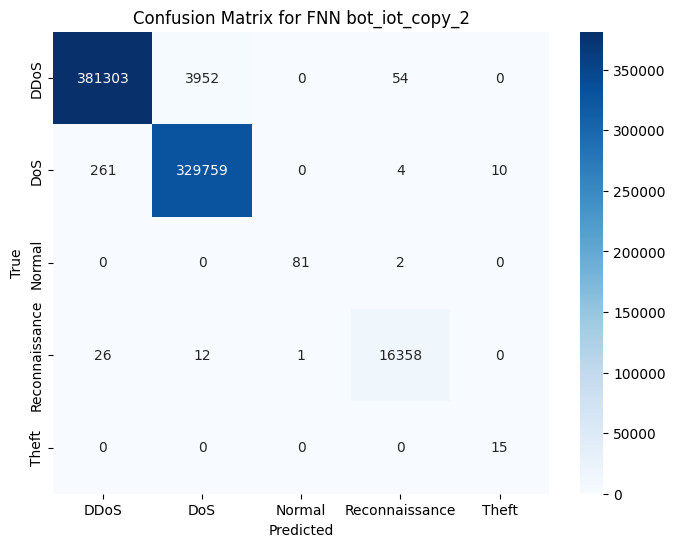

                precision    recall  f1-score   support

          DDoS       1.00      0.99      0.99    385309
           DoS       0.99      1.00      0.99    330034
        Normal       0.99      0.98      0.98        83
Reconnaissance       1.00      1.00      1.00     16397
         Theft       0.60      1.00      0.75        15

      accuracy                           0.99    731838
     macro avg       0.91      0.99      0.94    731838
  weighted avg       0.99      0.99      0.99    731838



Evaluating SNN for dataset: bot_iot_copy_2


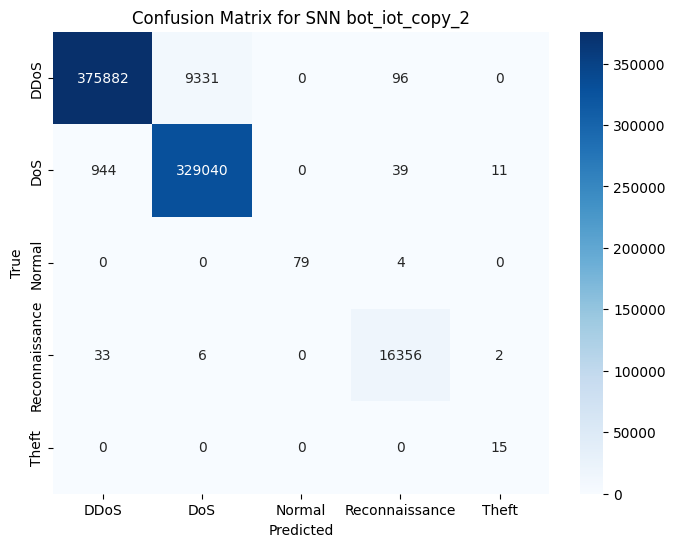

                precision    recall  f1-score   support

          DDoS       1.00      0.98      0.99    385309
           DoS       0.97      1.00      0.98    330034
        Normal       1.00      0.95      0.98        83
Reconnaissance       0.99      1.00      0.99     16397
         Theft       0.54      1.00      0.70        15

      accuracy                           0.99    731838
     macro avg       0.90      0.98      0.93    731838
  weighted avg       0.99      0.99      0.99    731838



ctu_13_copy_2:
Evaluating FNN for dataset: ctu_13_copy_2


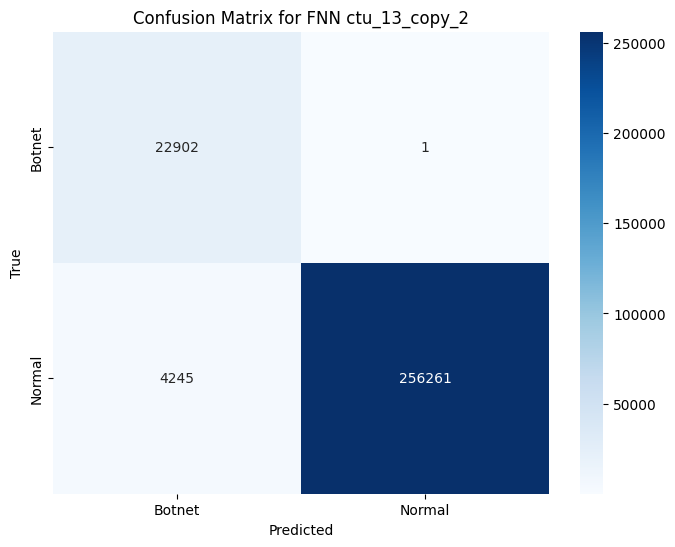

              precision    recall  f1-score   support

      Botnet       0.84      1.00      0.92     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.99    283409
   macro avg       0.92      0.99      0.95    283409
weighted avg       0.99      0.99      0.99    283409



Evaluating SNN for dataset: ctu_13_copy_2


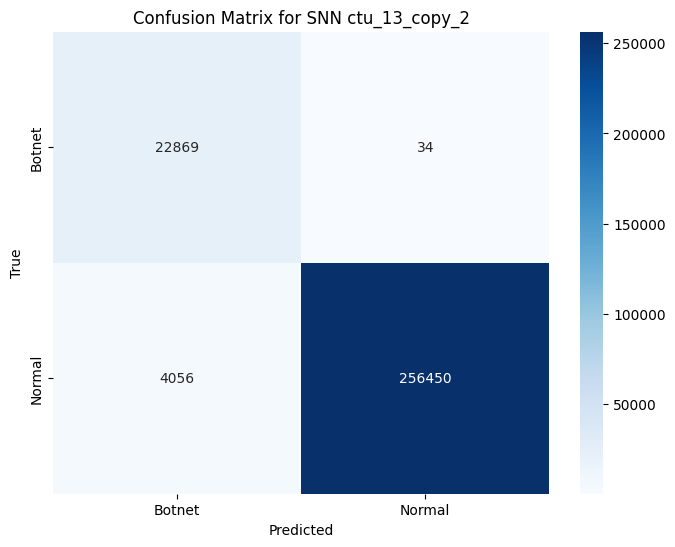

              precision    recall  f1-score   support

      Botnet       0.85      1.00      0.92     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.99    283409
   macro avg       0.92      0.99      0.96    283409
weighted avg       0.99      0.99      0.99    283409



nsl_kdd_copy_2:
Evaluating FNN for dataset: nsl_kdd_copy_2


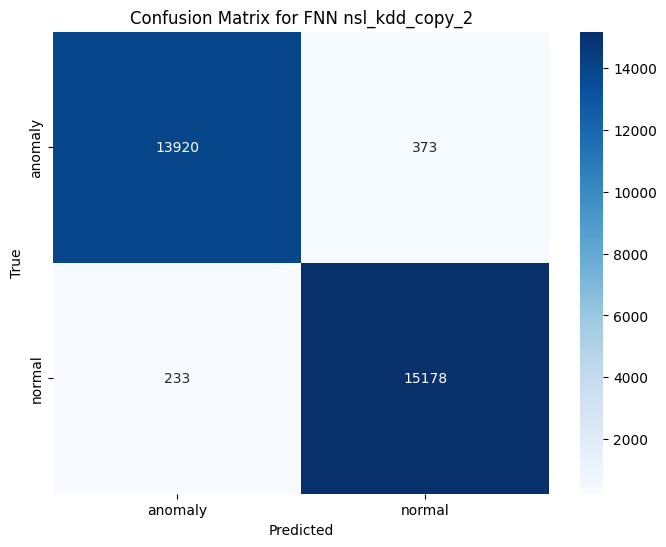

              precision    recall  f1-score   support

     anomaly       0.98      0.97      0.98     14293
      normal       0.98      0.98      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704



Evaluating SNN for dataset: nsl_kdd_copy_2


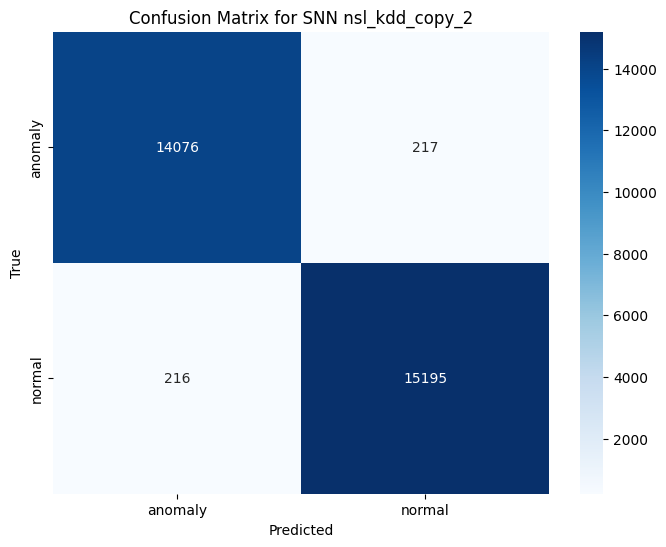

              precision    recall  f1-score   support

     anomaly       0.98      0.98      0.98     14293
      normal       0.99      0.99      0.99     15411

    accuracy                           0.99     29704
   macro avg       0.99      0.99      0.99     29704
weighted avg       0.99      0.99      0.99     29704



ton_iot_copy_3:
Evaluating FNN for dataset: ton_iot_copy_3


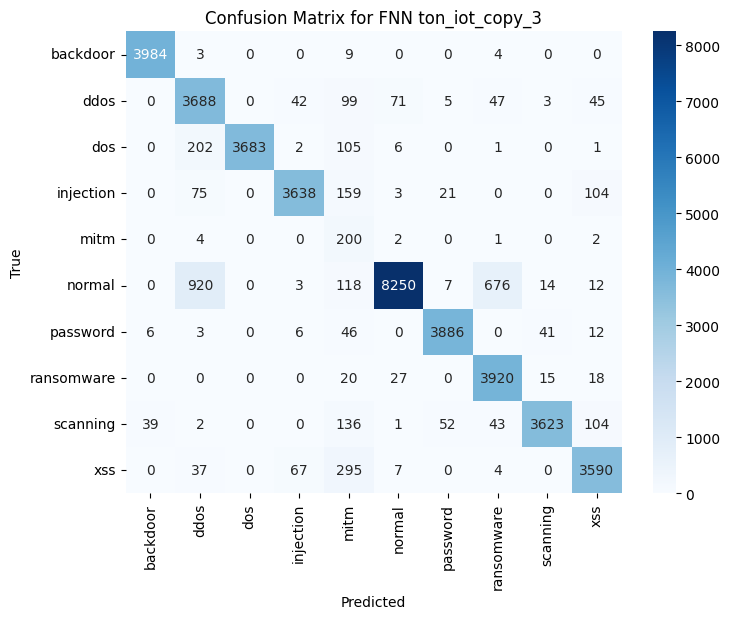

              precision    recall  f1-score   support

    backdoor       0.99      1.00      0.99      4000
        ddos       0.75      0.92      0.83      4000
         dos       1.00      0.92      0.96      4000
   injection       0.97      0.91      0.94      4000
        mitm       0.17      0.96      0.29       209
      normal       0.99      0.82      0.90     10000
    password       0.98      0.97      0.98      4000
  ransomware       0.83      0.98      0.90      4000
    scanning       0.98      0.91      0.94      4000
         xss       0.92      0.90      0.91      4000

    accuracy                           0.91     42209
   macro avg       0.86      0.93      0.86     42209
weighted avg       0.94      0.91      0.92     42209



Evaluating SNN for dataset: ton_iot_copy_3


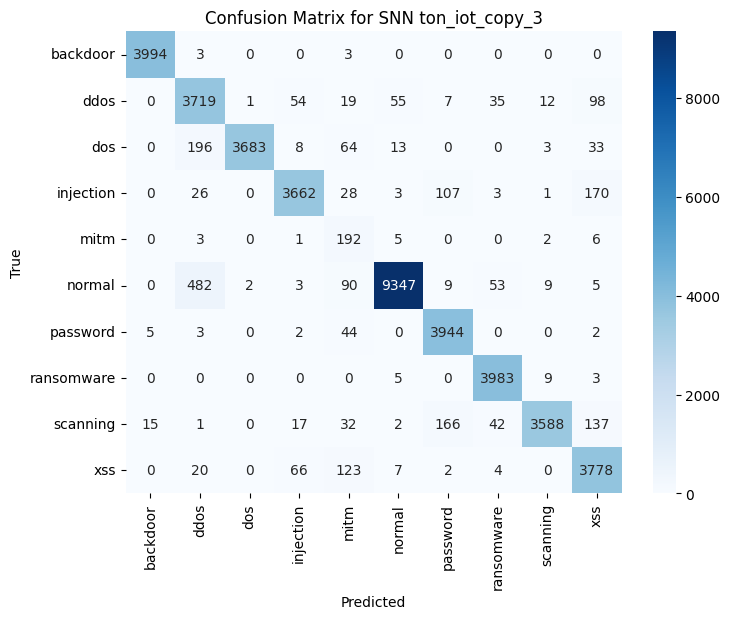

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.84      0.93      0.88      4000
         dos       1.00      0.92      0.96      4000
   injection       0.96      0.92      0.94      4000
        mitm       0.32      0.92      0.48       209
      normal       0.99      0.93      0.96     10000
    password       0.93      0.99      0.96      4000
  ransomware       0.97      1.00      0.98      4000
    scanning       0.99      0.90      0.94      4000
         xss       0.89      0.94      0.92      4000

    accuracy                           0.95     42209
   macro avg       0.89      0.94      0.90     42209
weighted avg       0.95      0.95      0.95     42209



bot_iot_copy_3:
Evaluating FNN for dataset: bot_iot_copy_3


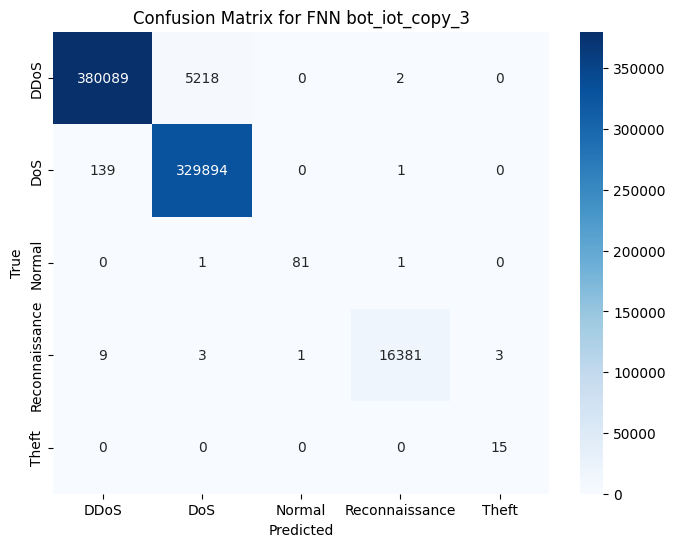

                precision    recall  f1-score   support

          DDoS       1.00      0.99      0.99    385309
           DoS       0.98      1.00      0.99    330034
        Normal       0.99      0.98      0.98        83
Reconnaissance       1.00      1.00      1.00     16397
         Theft       0.83      1.00      0.91        15

      accuracy                           0.99    731838
     macro avg       0.96      0.99      0.98    731838
  weighted avg       0.99      0.99      0.99    731838



Evaluating SNN for dataset: bot_iot_copy_3


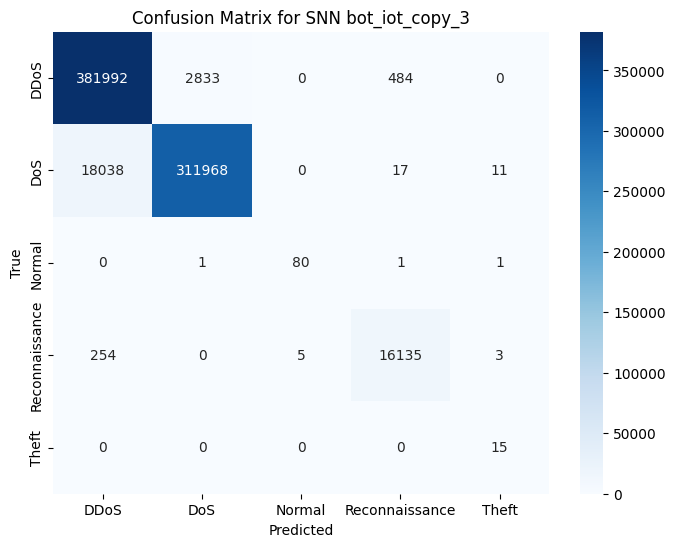

                precision    recall  f1-score   support

          DDoS       0.95      0.99      0.97    385309
           DoS       0.99      0.95      0.97    330034
        Normal       0.94      0.96      0.95        83
Reconnaissance       0.97      0.98      0.98     16397
         Theft       0.50      1.00      0.67        15

      accuracy                           0.97    731838
     macro avg       0.87      0.98      0.91    731838
  weighted avg       0.97      0.97      0.97    731838



ctu_13_copy_3:
Evaluating FNN for dataset: ctu_13_copy_3


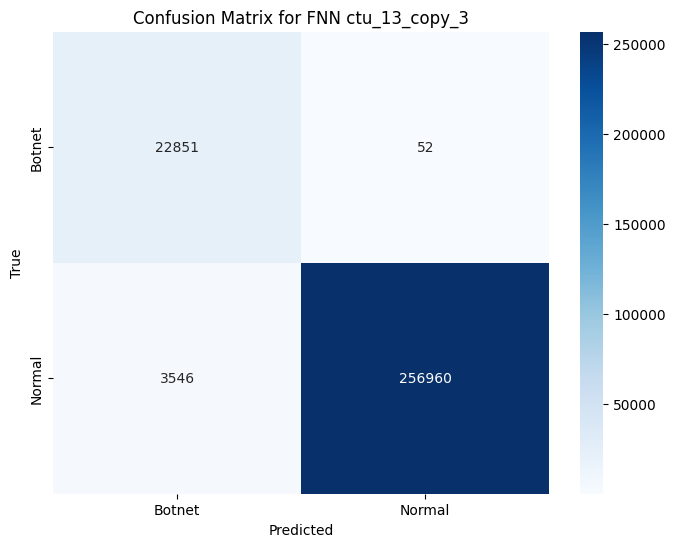

              precision    recall  f1-score   support

      Botnet       0.87      1.00      0.93     22903
      Normal       1.00      0.99      0.99    260506

    accuracy                           0.99    283409
   macro avg       0.93      0.99      0.96    283409
weighted avg       0.99      0.99      0.99    283409



Evaluating SNN for dataset: ctu_13_copy_3


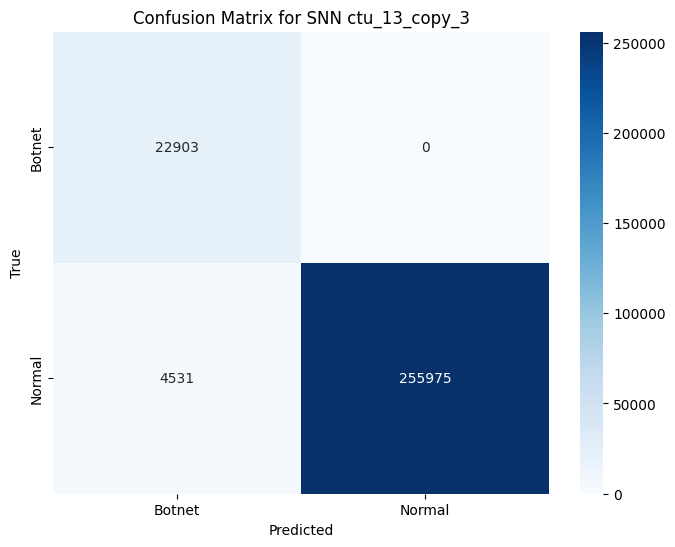

              precision    recall  f1-score   support

      Botnet       0.83      1.00      0.91     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.98    283409
   macro avg       0.92      0.99      0.95    283409
weighted avg       0.99      0.98      0.98    283409



nsl_kdd_copy_3:
Evaluating FNN for dataset: nsl_kdd_copy_3


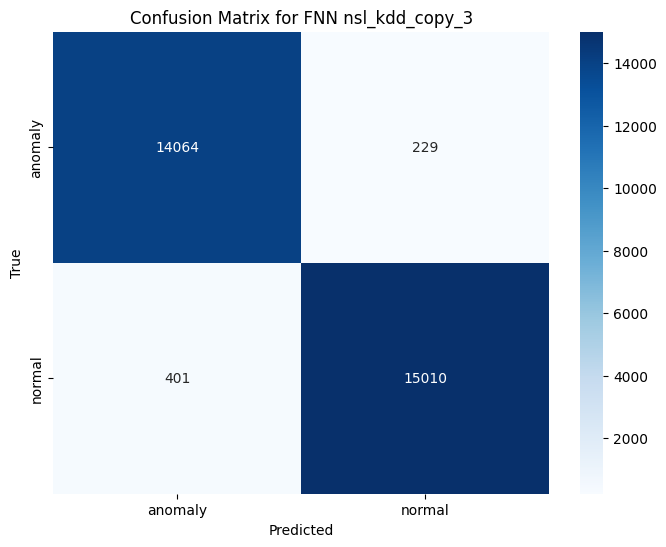

              precision    recall  f1-score   support

     anomaly       0.97      0.98      0.98     14293
      normal       0.98      0.97      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704



Evaluating SNN for dataset: nsl_kdd_copy_3


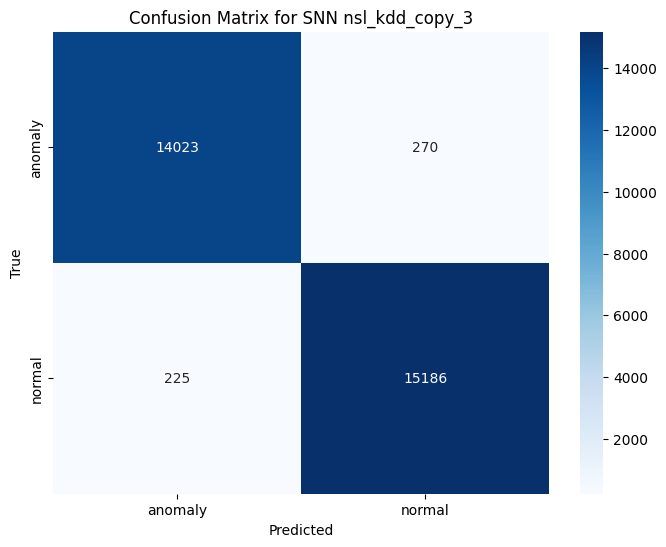

              precision    recall  f1-score   support

     anomaly       0.98      0.98      0.98     14293
      normal       0.98      0.99      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704



ton_iot_copy_4:
Evaluating FNN for dataset: ton_iot_copy_4


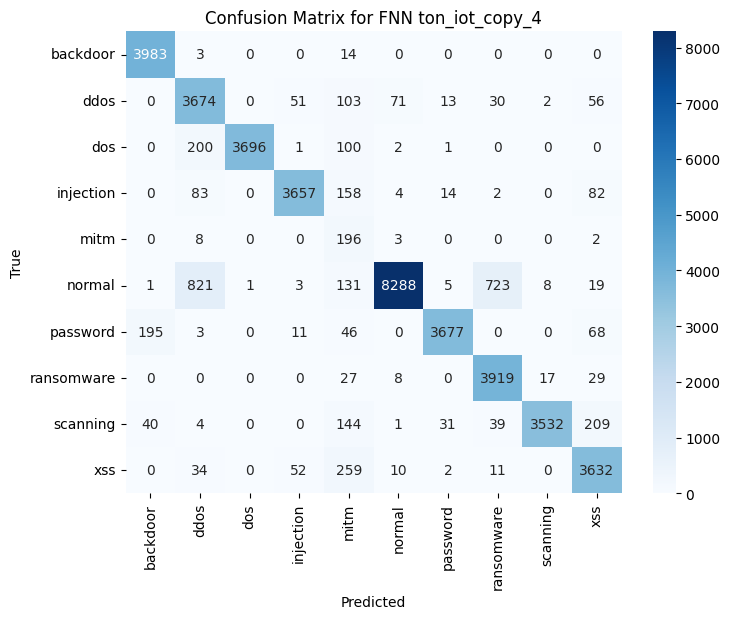

              precision    recall  f1-score   support

    backdoor       0.94      1.00      0.97      4000
        ddos       0.76      0.92      0.83      4000
         dos       1.00      0.92      0.96      4000
   injection       0.97      0.91      0.94      4000
        mitm       0.17      0.94      0.28       209
      normal       0.99      0.83      0.90     10000
    password       0.98      0.92      0.95      4000
  ransomware       0.83      0.98      0.90      4000
    scanning       0.99      0.88      0.93      4000
         xss       0.89      0.91      0.90      4000

    accuracy                           0.91     42209
   macro avg       0.85      0.92      0.86     42209
weighted avg       0.93      0.91      0.91     42209



Evaluating SNN for dataset: ton_iot_copy_4


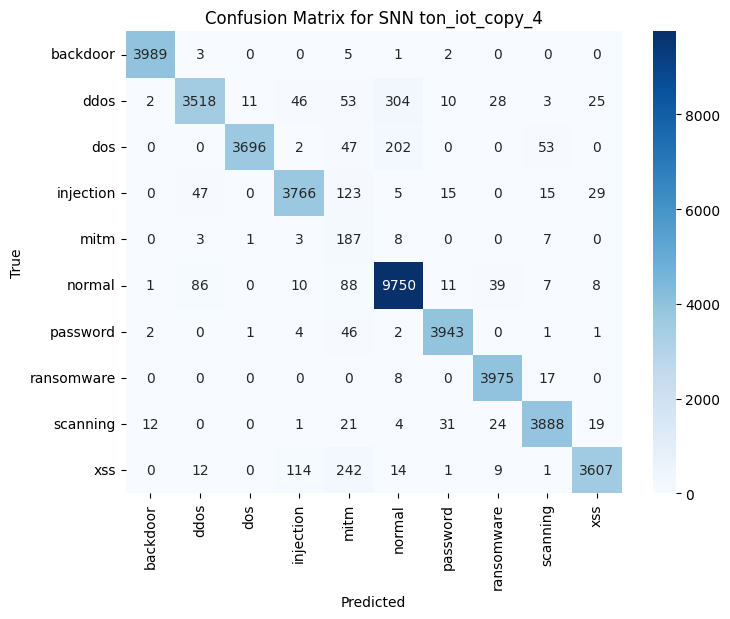

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.96      0.88      0.92      4000
         dos       1.00      0.92      0.96      4000
   injection       0.95      0.94      0.95      4000
        mitm       0.23      0.89      0.37       209
      normal       0.95      0.97      0.96     10000
    password       0.98      0.99      0.98      4000
  ransomware       0.98      0.99      0.98      4000
    scanning       0.97      0.97      0.97      4000
         xss       0.98      0.90      0.94      4000

    accuracy                           0.96     42209
   macro avg       0.90      0.95      0.90     42209
weighted avg       0.97      0.96      0.96     42209



bot_iot_copy_4:
Evaluating FNN for dataset: bot_iot_copy_4


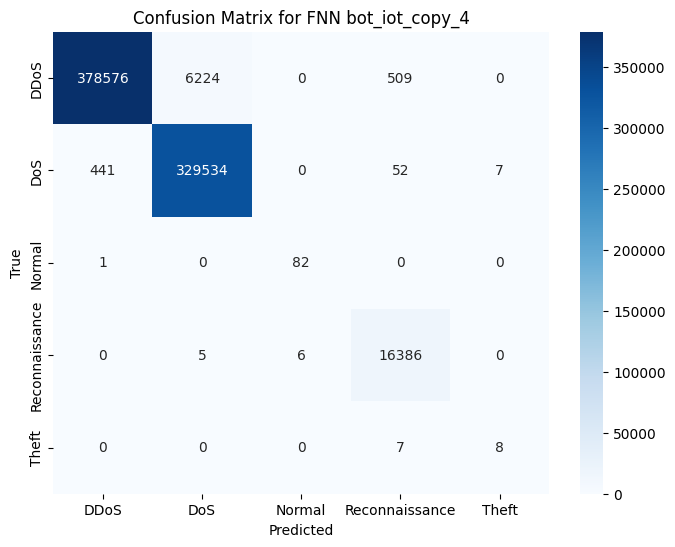

                precision    recall  f1-score   support

          DDoS       1.00      0.98      0.99    385309
           DoS       0.98      1.00      0.99    330034
        Normal       0.93      0.99      0.96        83
Reconnaissance       0.97      1.00      0.98     16397
         Theft       0.53      0.53      0.53        15

      accuracy                           0.99    731838
     macro avg       0.88      0.90      0.89    731838
  weighted avg       0.99      0.99      0.99    731838



Evaluating SNN for dataset: bot_iot_copy_4


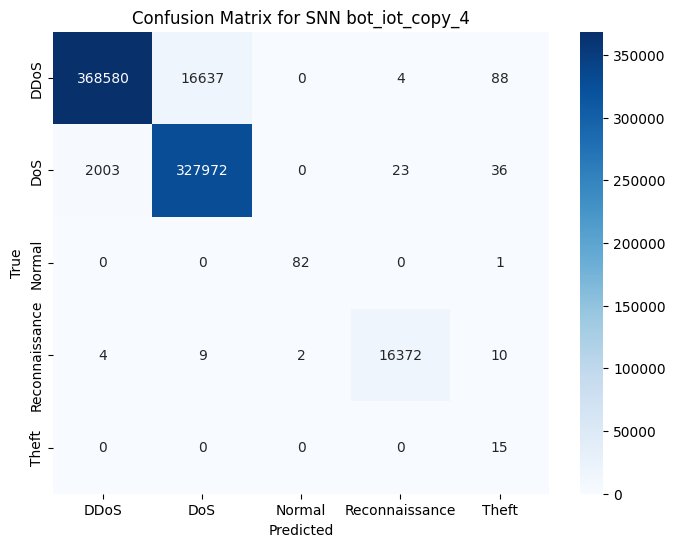

                precision    recall  f1-score   support

          DDoS       0.99      0.96      0.98    385309
           DoS       0.95      0.99      0.97    330034
        Normal       0.98      0.99      0.98        83
Reconnaissance       1.00      1.00      1.00     16397
         Theft       0.10      1.00      0.18        15

      accuracy                           0.97    731838
     macro avg       0.80      0.99      0.82    731838
  weighted avg       0.98      0.97      0.97    731838



ctu_13_copy_4:
Evaluating FNN for dataset: ctu_13_copy_4


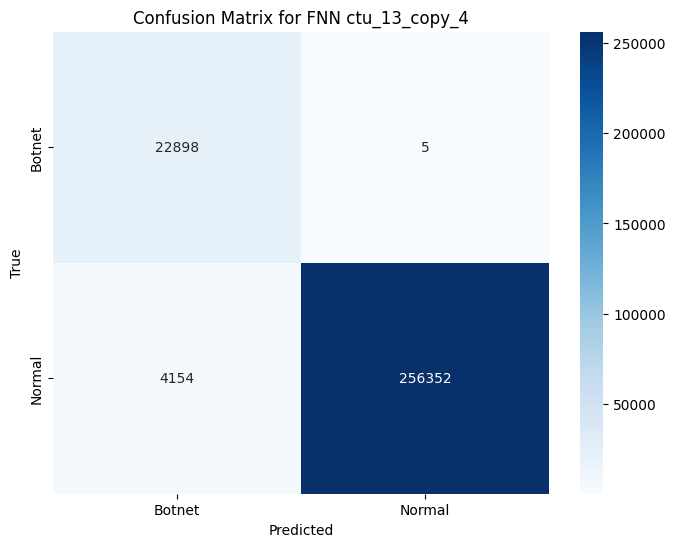

              precision    recall  f1-score   support

      Botnet       0.85      1.00      0.92     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.99    283409
   macro avg       0.92      0.99      0.95    283409
weighted avg       0.99      0.99      0.99    283409



Evaluating SNN for dataset: ctu_13_copy_4


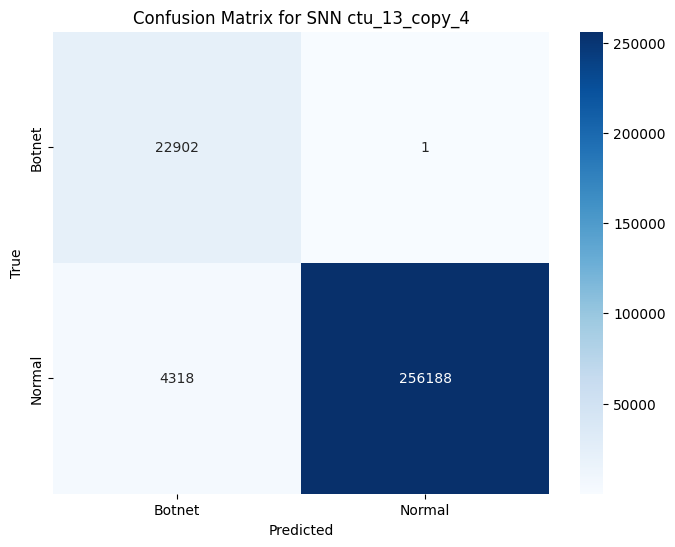

              precision    recall  f1-score   support

      Botnet       0.84      1.00      0.91     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.98    283409
   macro avg       0.92      0.99      0.95    283409
weighted avg       0.99      0.98      0.99    283409



nsl_kdd_copy_4:
Evaluating FNN for dataset: nsl_kdd_copy_4


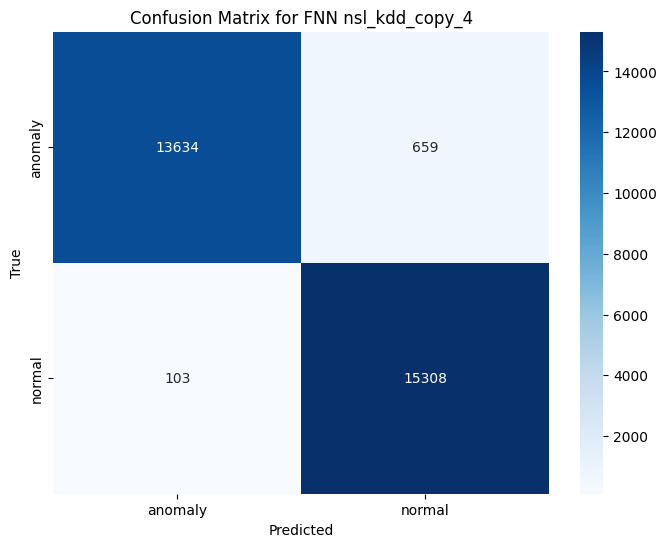

              precision    recall  f1-score   support

     anomaly       0.99      0.95      0.97     14293
      normal       0.96      0.99      0.98     15411

    accuracy                           0.97     29704
   macro avg       0.98      0.97      0.97     29704
weighted avg       0.97      0.97      0.97     29704



Evaluating SNN for dataset: nsl_kdd_copy_4


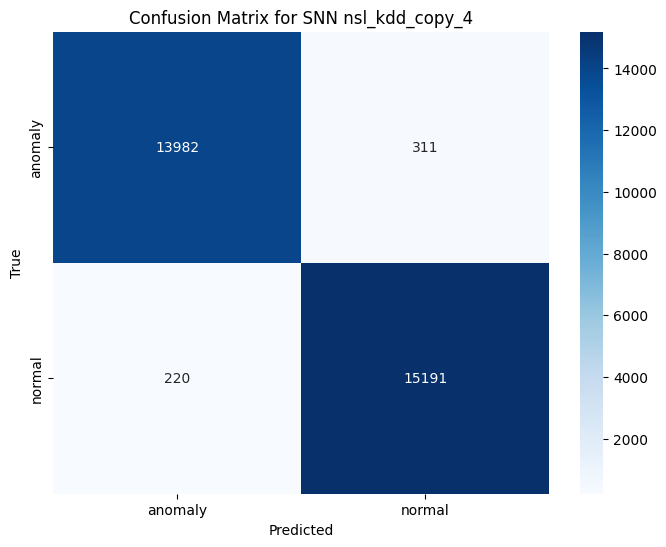

              precision    recall  f1-score   support

     anomaly       0.98      0.98      0.98     14293
      normal       0.98      0.99      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704



ton_iot_copy_5:
Evaluating FNN for dataset: ton_iot_copy_5


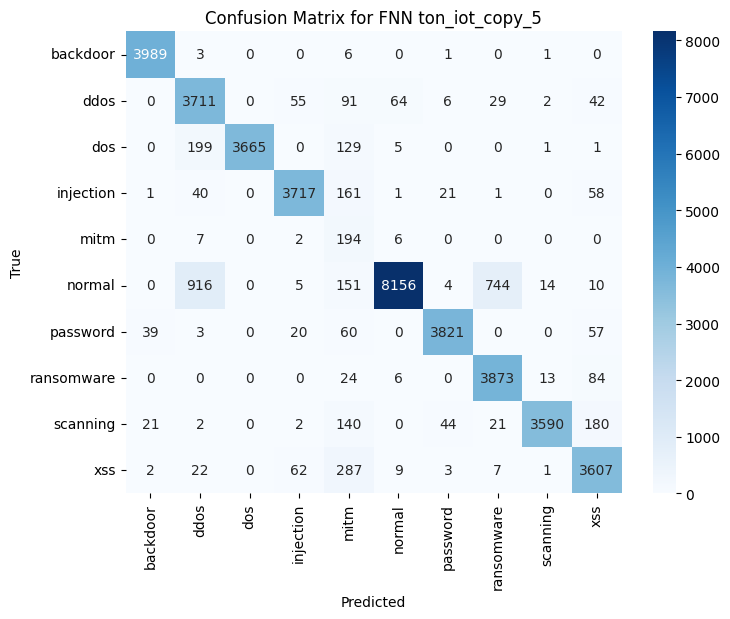

              precision    recall  f1-score   support

    backdoor       0.98      1.00      0.99      4000
        ddos       0.76      0.93      0.83      4000
         dos       1.00      0.92      0.96      4000
   injection       0.96      0.93      0.95      4000
        mitm       0.16      0.93      0.27       209
      normal       0.99      0.82      0.89     10000
    password       0.98      0.96      0.97      4000
  ransomware       0.83      0.97      0.89      4000
    scanning       0.99      0.90      0.94      4000
         xss       0.89      0.90      0.90      4000

    accuracy                           0.91     42209
   macro avg       0.85      0.92      0.86     42209
weighted avg       0.94      0.91      0.92     42209



Evaluating SNN for dataset: ton_iot_copy_5


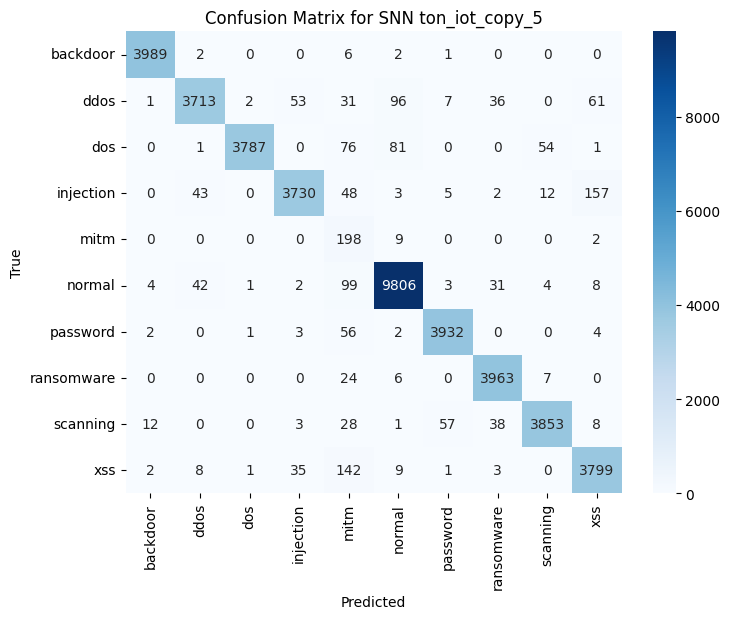

              precision    recall  f1-score   support

    backdoor       0.99      1.00      1.00      4000
        ddos       0.97      0.93      0.95      4000
         dos       1.00      0.95      0.97      4000
   injection       0.97      0.93      0.95      4000
        mitm       0.28      0.95      0.43       209
      normal       0.98      0.98      0.98     10000
    password       0.98      0.98      0.98      4000
  ransomware       0.97      0.99      0.98      4000
    scanning       0.98      0.96      0.97      4000
         xss       0.94      0.95      0.95      4000

    accuracy                           0.97     42209
   macro avg       0.91      0.96      0.92     42209
weighted avg       0.97      0.97      0.97     42209



bot_iot_copy_5:
Evaluating FNN for dataset: bot_iot_copy_5


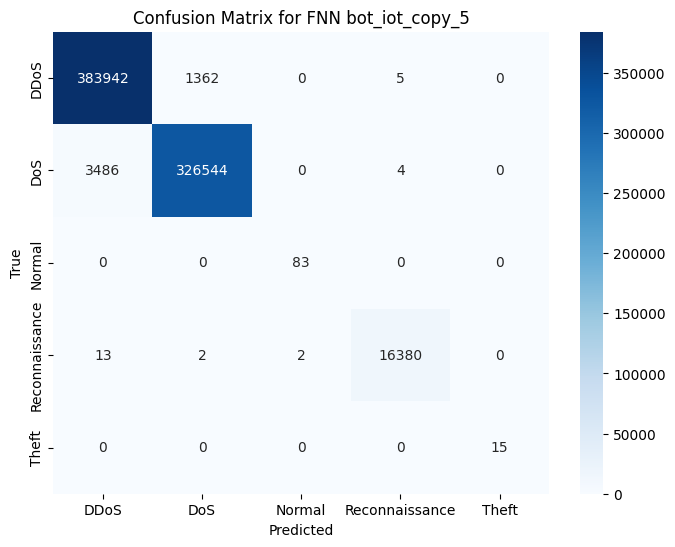

                precision    recall  f1-score   support

          DDoS       0.99      1.00      0.99    385309
           DoS       1.00      0.99      0.99    330034
        Normal       0.98      1.00      0.99        83
Reconnaissance       1.00      1.00      1.00     16397
         Theft       1.00      1.00      1.00        15

      accuracy                           0.99    731838
     macro avg       0.99      1.00      0.99    731838
  weighted avg       0.99      0.99      0.99    731838



Evaluating SNN for dataset: bot_iot_copy_5


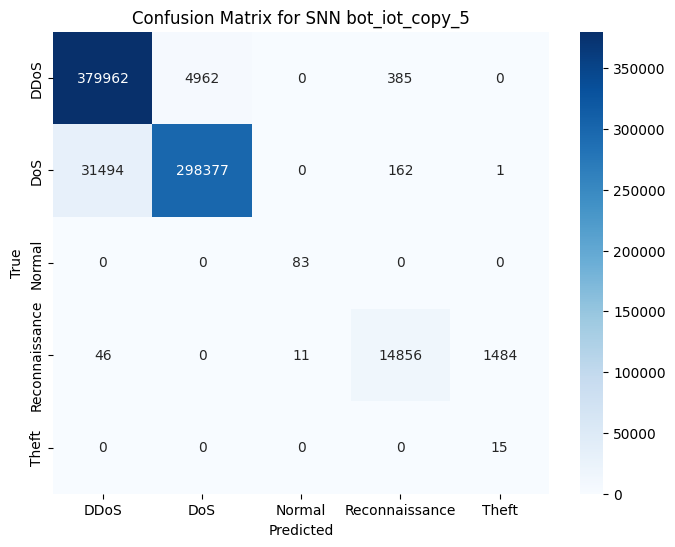

                precision    recall  f1-score   support

          DDoS       0.92      0.99      0.95    385309
           DoS       0.98      0.90      0.94    330034
        Normal       0.88      1.00      0.94        83
Reconnaissance       0.96      0.91      0.93     16397
         Theft       0.01      1.00      0.02        15

      accuracy                           0.95    731838
     macro avg       0.75      0.96      0.76    731838
  weighted avg       0.95      0.95      0.95    731838



ctu_13_copy_5:
Evaluating FNN for dataset: ctu_13_copy_5


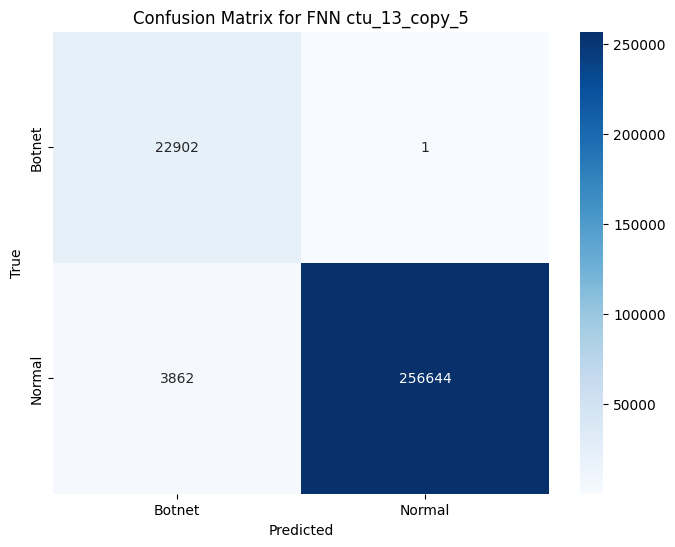

              precision    recall  f1-score   support

      Botnet       0.86      1.00      0.92     22903
      Normal       1.00      0.99      0.99    260506

    accuracy                           0.99    283409
   macro avg       0.93      0.99      0.96    283409
weighted avg       0.99      0.99      0.99    283409



Evaluating SNN for dataset: ctu_13_copy_5


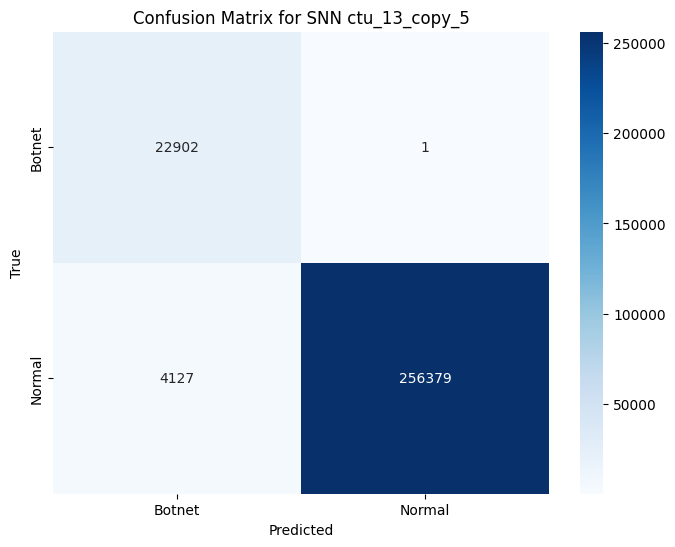

              precision    recall  f1-score   support

      Botnet       0.85      1.00      0.92     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.99    283409
   macro avg       0.92      0.99      0.95    283409
weighted avg       0.99      0.99      0.99    283409



nsl_kdd_copy_5:
Evaluating FNN for dataset: nsl_kdd_copy_5


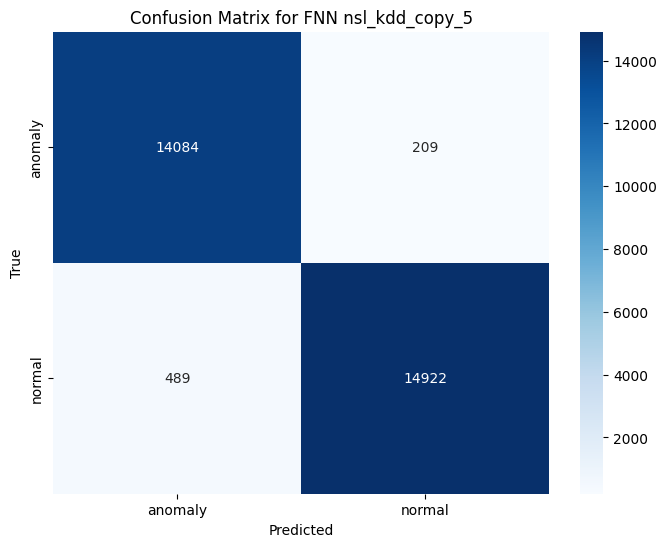

              precision    recall  f1-score   support

     anomaly       0.97      0.99      0.98     14293
      normal       0.99      0.97      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704



Evaluating SNN for dataset: nsl_kdd_copy_5


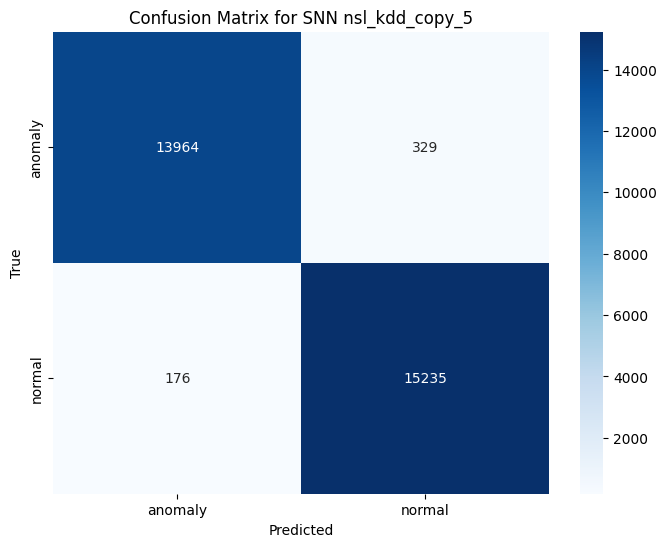

              precision    recall  f1-score   support

     anomaly       0.99      0.98      0.98     14293
      normal       0.98      0.99      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704



ton_iot_copy_6:
Evaluating FNN for dataset: ton_iot_copy_6


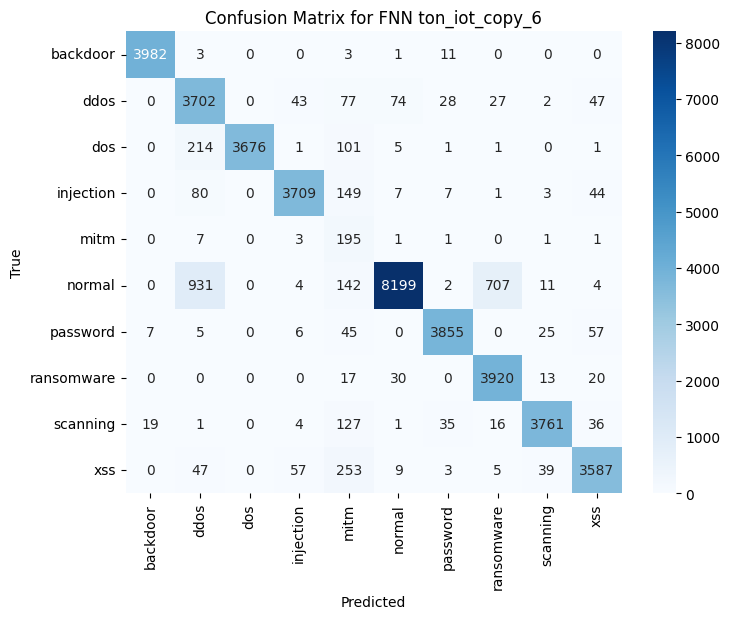

              precision    recall  f1-score   support

    backdoor       0.99      1.00      0.99      4000
        ddos       0.74      0.93      0.82      4000
         dos       1.00      0.92      0.96      4000
   injection       0.97      0.93      0.95      4000
        mitm       0.18      0.93      0.30       209
      normal       0.98      0.82      0.89     10000
    password       0.98      0.96      0.97      4000
  ransomware       0.84      0.98      0.90      4000
    scanning       0.98      0.94      0.96      4000
         xss       0.94      0.90      0.92      4000

    accuracy                           0.91     42209
   macro avg       0.86      0.93      0.87     42209
weighted avg       0.94      0.91      0.92     42209



Evaluating SNN for dataset: ton_iot_copy_6


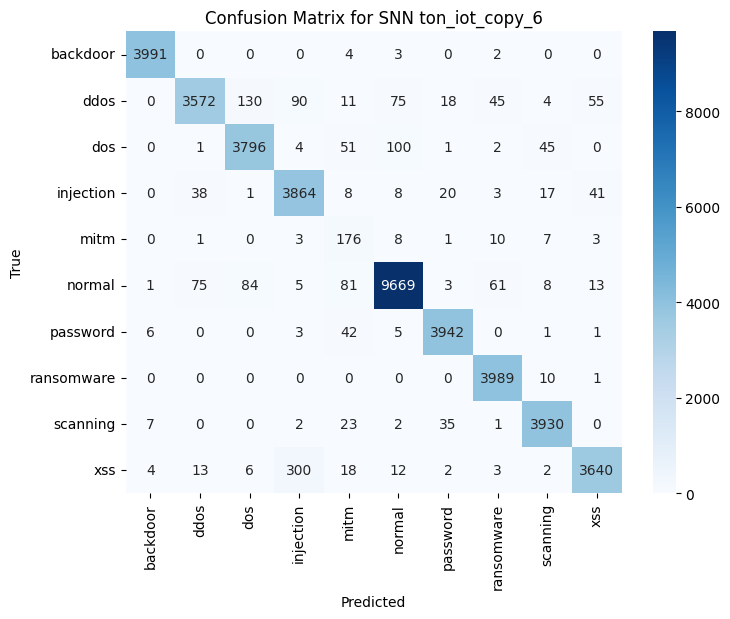

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.97      0.89      0.93      4000
         dos       0.94      0.95      0.95      4000
   injection       0.90      0.97      0.93      4000
        mitm       0.43      0.84      0.57       209
      normal       0.98      0.97      0.97     10000
    password       0.98      0.99      0.98      4000
  ransomware       0.97      1.00      0.98      4000
    scanning       0.98      0.98      0.98      4000
         xss       0.97      0.91      0.94      4000

    accuracy                           0.96     42209
   macro avg       0.91      0.95      0.92     42209
weighted avg       0.96      0.96      0.96     42209



bot_iot_copy_6:
Evaluating FNN for dataset: bot_iot_copy_6


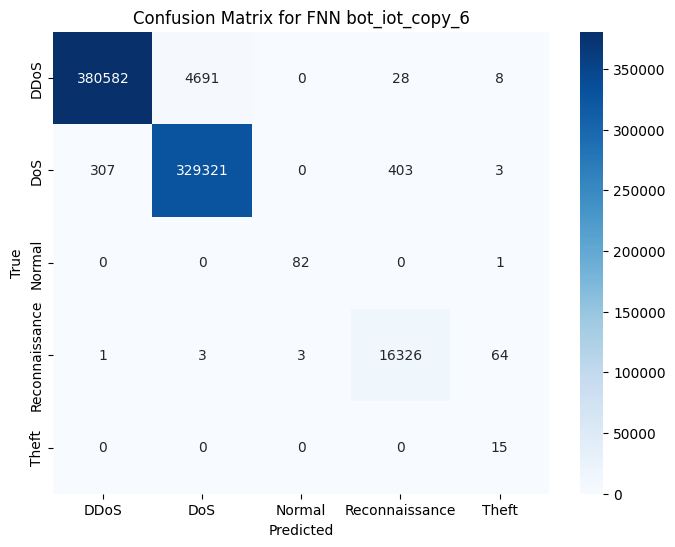

                precision    recall  f1-score   support

          DDoS       1.00      0.99      0.99    385309
           DoS       0.99      1.00      0.99    330034
        Normal       0.96      0.99      0.98        83
Reconnaissance       0.97      1.00      0.98     16397
         Theft       0.16      1.00      0.28        15

      accuracy                           0.99    731838
     macro avg       0.82      0.99      0.85    731838
  weighted avg       0.99      0.99      0.99    731838



Evaluating SNN for dataset: bot_iot_copy_6


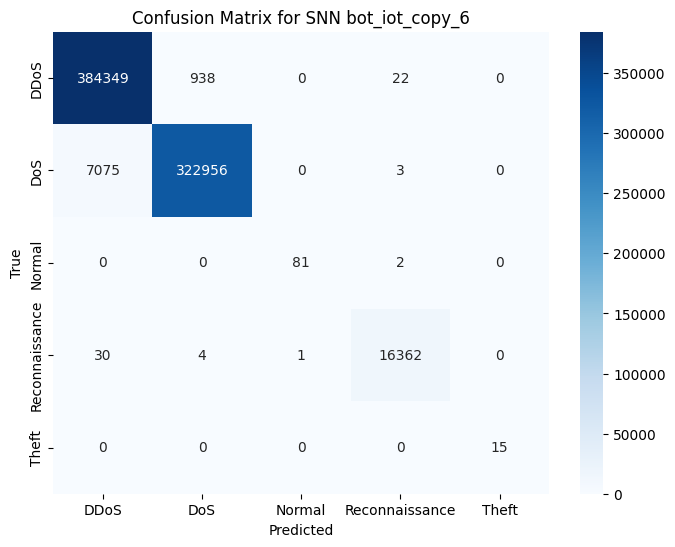

                precision    recall  f1-score   support

          DDoS       0.98      1.00      0.99    385309
           DoS       1.00      0.98      0.99    330034
        Normal       0.99      0.98      0.98        83
Reconnaissance       1.00      1.00      1.00     16397
         Theft       1.00      1.00      1.00        15

      accuracy                           0.99    731838
     macro avg       0.99      0.99      0.99    731838
  weighted avg       0.99      0.99      0.99    731838



ctu_13_copy_6:
Evaluating FNN for dataset: ctu_13_copy_6


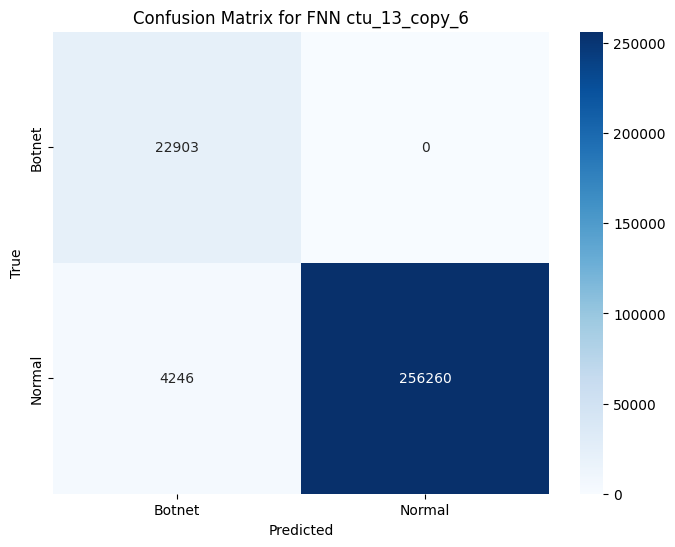

              precision    recall  f1-score   support

      Botnet       0.84      1.00      0.92     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.99    283409
   macro avg       0.92      0.99      0.95    283409
weighted avg       0.99      0.99      0.99    283409



Evaluating SNN for dataset: ctu_13_copy_6


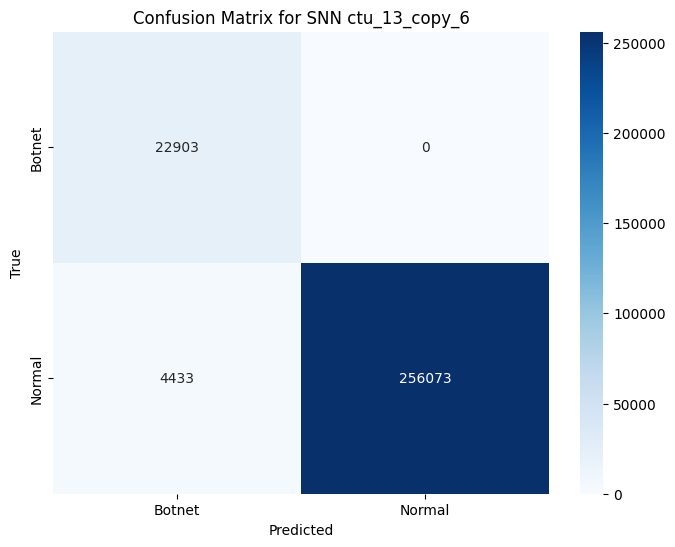

              precision    recall  f1-score   support

      Botnet       0.84      1.00      0.91     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.98    283409
   macro avg       0.92      0.99      0.95    283409
weighted avg       0.99      0.98      0.98    283409



nsl_kdd_copy_6:
Evaluating FNN for dataset: nsl_kdd_copy_6


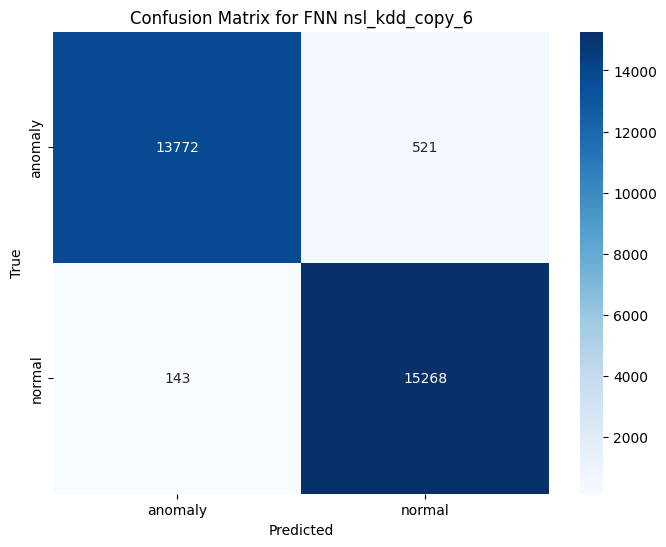

              precision    recall  f1-score   support

     anomaly       0.99      0.96      0.98     14293
      normal       0.97      0.99      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704



Evaluating SNN for dataset: nsl_kdd_copy_6


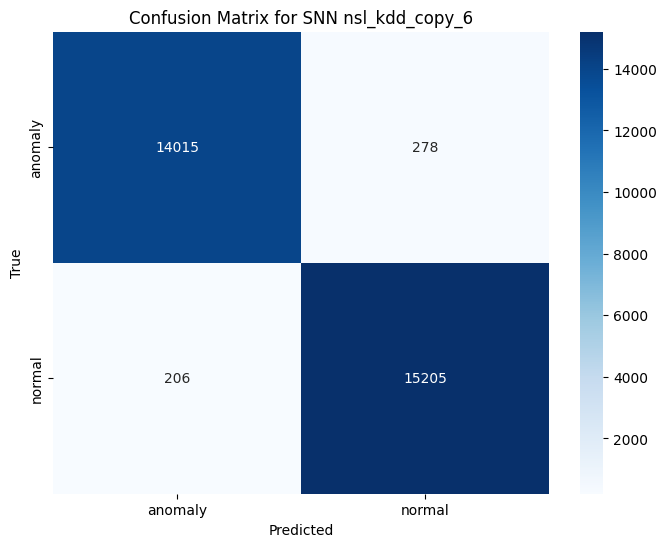

              precision    recall  f1-score   support

     anomaly       0.99      0.98      0.98     14293
      normal       0.98      0.99      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704



ton_iot_copy_7:
Evaluating FNN for dataset: ton_iot_copy_7


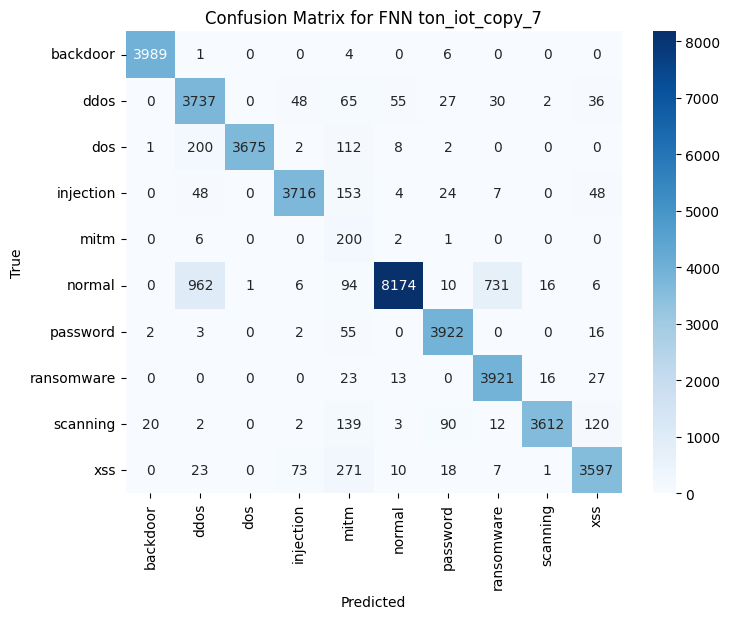

              precision    recall  f1-score   support

    backdoor       0.99      1.00      1.00      4000
        ddos       0.75      0.93      0.83      4000
         dos       1.00      0.92      0.96      4000
   injection       0.97      0.93      0.95      4000
        mitm       0.18      0.96      0.30       209
      normal       0.99      0.82      0.89     10000
    password       0.96      0.98      0.97      4000
  ransomware       0.83      0.98      0.90      4000
    scanning       0.99      0.90      0.94      4000
         xss       0.93      0.90      0.92      4000

    accuracy                           0.91     42209
   macro avg       0.86      0.93      0.87     42209
weighted avg       0.94      0.91      0.92     42209



Evaluating SNN for dataset: ton_iot_copy_7


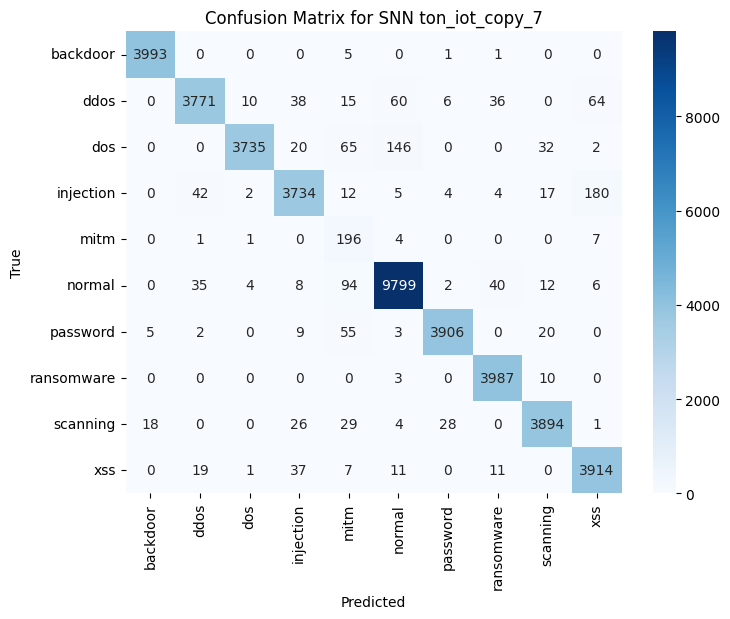

              precision    recall  f1-score   support

    backdoor       0.99      1.00      1.00      4000
        ddos       0.97      0.94      0.96      4000
         dos       1.00      0.93      0.96      4000
   injection       0.96      0.93      0.95      4000
        mitm       0.41      0.94      0.57       209
      normal       0.98      0.98      0.98     10000
    password       0.99      0.98      0.98      4000
  ransomware       0.98      1.00      0.99      4000
    scanning       0.98      0.97      0.98      4000
         xss       0.94      0.98      0.96      4000

    accuracy                           0.97     42209
   macro avg       0.92      0.97      0.93     42209
weighted avg       0.97      0.97      0.97     42209



bot_iot_copy_7:
Evaluating FNN for dataset: bot_iot_copy_7


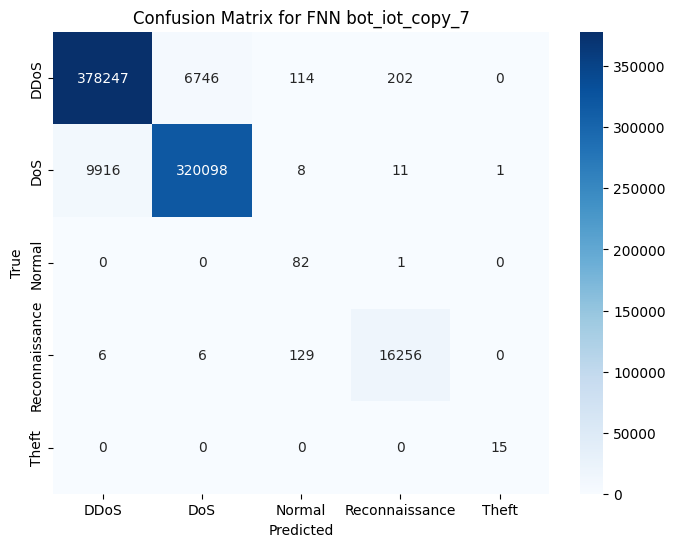

                precision    recall  f1-score   support

          DDoS       0.97      0.98      0.98    385309
           DoS       0.98      0.97      0.97    330034
        Normal       0.25      0.99      0.39        83
Reconnaissance       0.99      0.99      0.99     16397
         Theft       0.94      1.00      0.97        15

      accuracy                           0.98    731838
     macro avg       0.82      0.99      0.86    731838
  weighted avg       0.98      0.98      0.98    731838



Evaluating SNN for dataset: bot_iot_copy_7


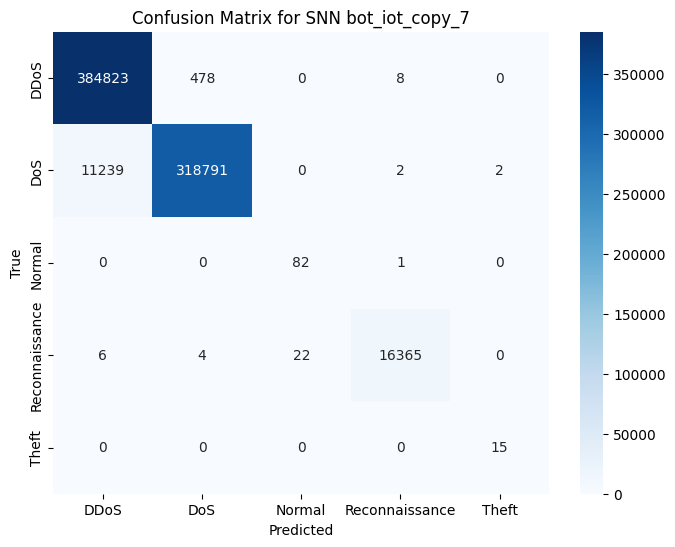

                precision    recall  f1-score   support

          DDoS       0.97      1.00      0.98    385309
           DoS       1.00      0.97      0.98    330034
        Normal       0.79      0.99      0.88        83
Reconnaissance       1.00      1.00      1.00     16397
         Theft       0.88      1.00      0.94        15

      accuracy                           0.98    731838
     macro avg       0.93      0.99      0.96    731838
  weighted avg       0.98      0.98      0.98    731838



ctu_13_copy_7:
Evaluating FNN for dataset: ctu_13_copy_7


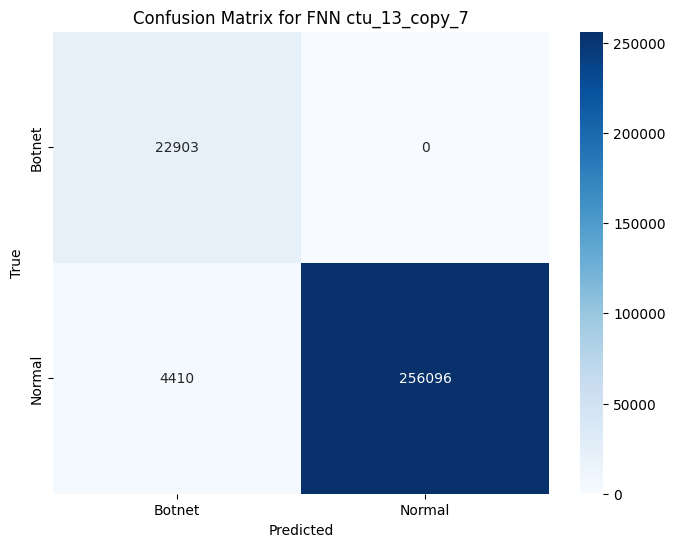

              precision    recall  f1-score   support

      Botnet       0.84      1.00      0.91     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.98    283409
   macro avg       0.92      0.99      0.95    283409
weighted avg       0.99      0.98      0.99    283409



Evaluating SNN for dataset: ctu_13_copy_7


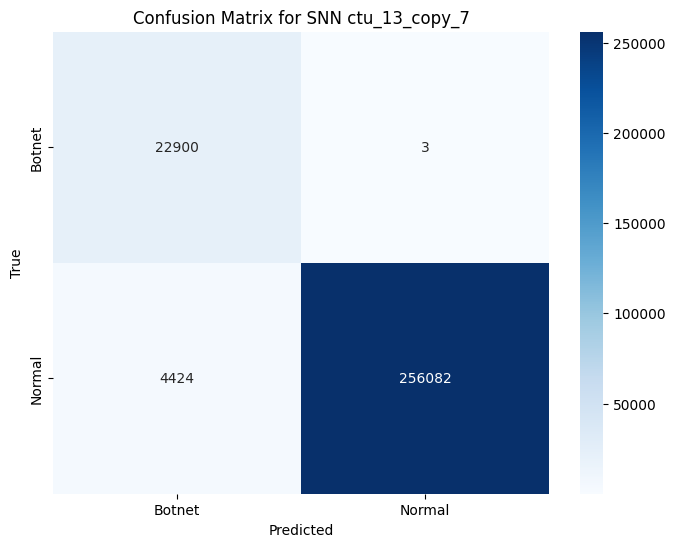

              precision    recall  f1-score   support

      Botnet       0.84      1.00      0.91     22903
      Normal       1.00      0.98      0.99    260506

    accuracy                           0.98    283409
   macro avg       0.92      0.99      0.95    283409
weighted avg       0.99      0.98      0.99    283409



nsl_kdd_copy_7:
Evaluating FNN for dataset: nsl_kdd_copy_7


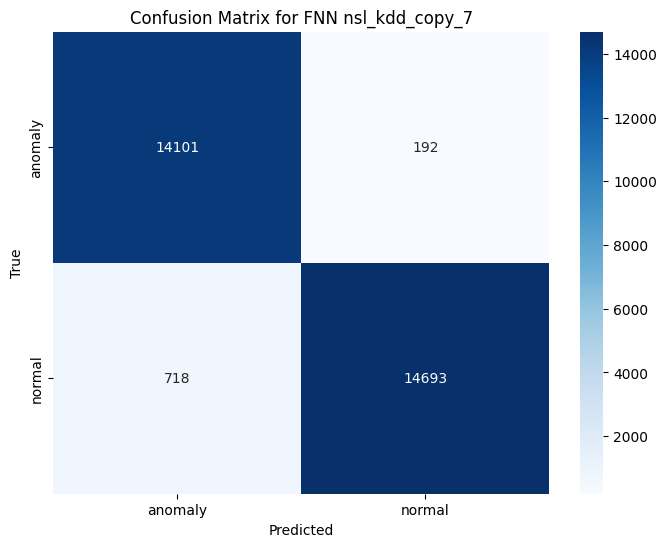

              precision    recall  f1-score   support

     anomaly       0.95      0.99      0.97     14293
      normal       0.99      0.95      0.97     15411

    accuracy                           0.97     29704
   macro avg       0.97      0.97      0.97     29704
weighted avg       0.97      0.97      0.97     29704



Evaluating SNN for dataset: nsl_kdd_copy_7


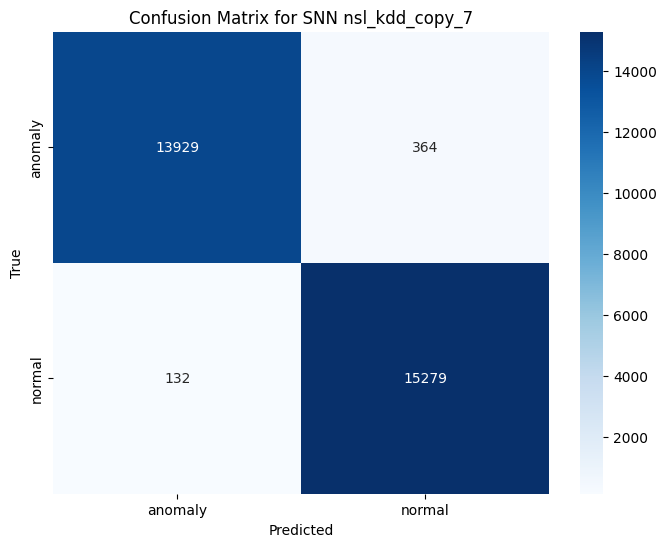

              precision    recall  f1-score   support

     anomaly       0.99      0.97      0.98     14293
      normal       0.98      0.99      0.98     15411

    accuracy                           0.98     29704
   macro avg       0.98      0.98      0.98     29704
weighted avg       0.98      0.98      0.98     29704





In [ ]:
for dataset_name, dataset in datasets.items():
    print(f"{dataset_name}:")
    for network in network_types:
        print(f"Evaluating {network.upper()} for dataset: {dataset_name}")
        dataset[f"{network}_trainer"].plot_confusion_matrix(dataset["dataPreparer"], title=f'Confusion Matrix for {network.upper()} {dataset_name}')
        network_report = dataset[f"{network}_trainer"].get_classification_report(dataset["dataPreparer"])
        print(network_report)
        print("\n" + "="*50 + "\n")